(a) true=1.2566  MAP=3.0968  MMSE=1.6509
(b) true=1.2566  MAP=1.2635  MMSE=1.5773  gap=0.3138
SNR -10.0 dB   MAP 1.044e+00   MMSE 6.375e-01
SNR  -8.0 dB   MAP 7.069e-01   MMSE 4.649e-01
SNR  -6.0 dB   MAP 4.332e-01   MMSE 3.023e-01
SNR  -4.0 dB   MAP 1.748e-01   MMSE 1.233e-01
SNR  -2.0 dB   MAP 3.619e-02   MMSE 2.911e-02
SNR  +0.0 dB   MAP 9.369e-05   MMSE 1.546e-04
SNR  +2.0 dB   MAP 5.468e-05   MMSE 5.356e-05
SNR  +4.0 dB   MAP 3.589e-05   MMSE 3.509e-05
SNR  +6.0 dB   MAP 2.449e-05   MMSE 2.438e-05
SNR  +8.0 dB   MAP 1.542e-05   MMSE 1.504e-05
SNR +10.0 dB   MAP 8.643e-06   MMSE 8.565e-06


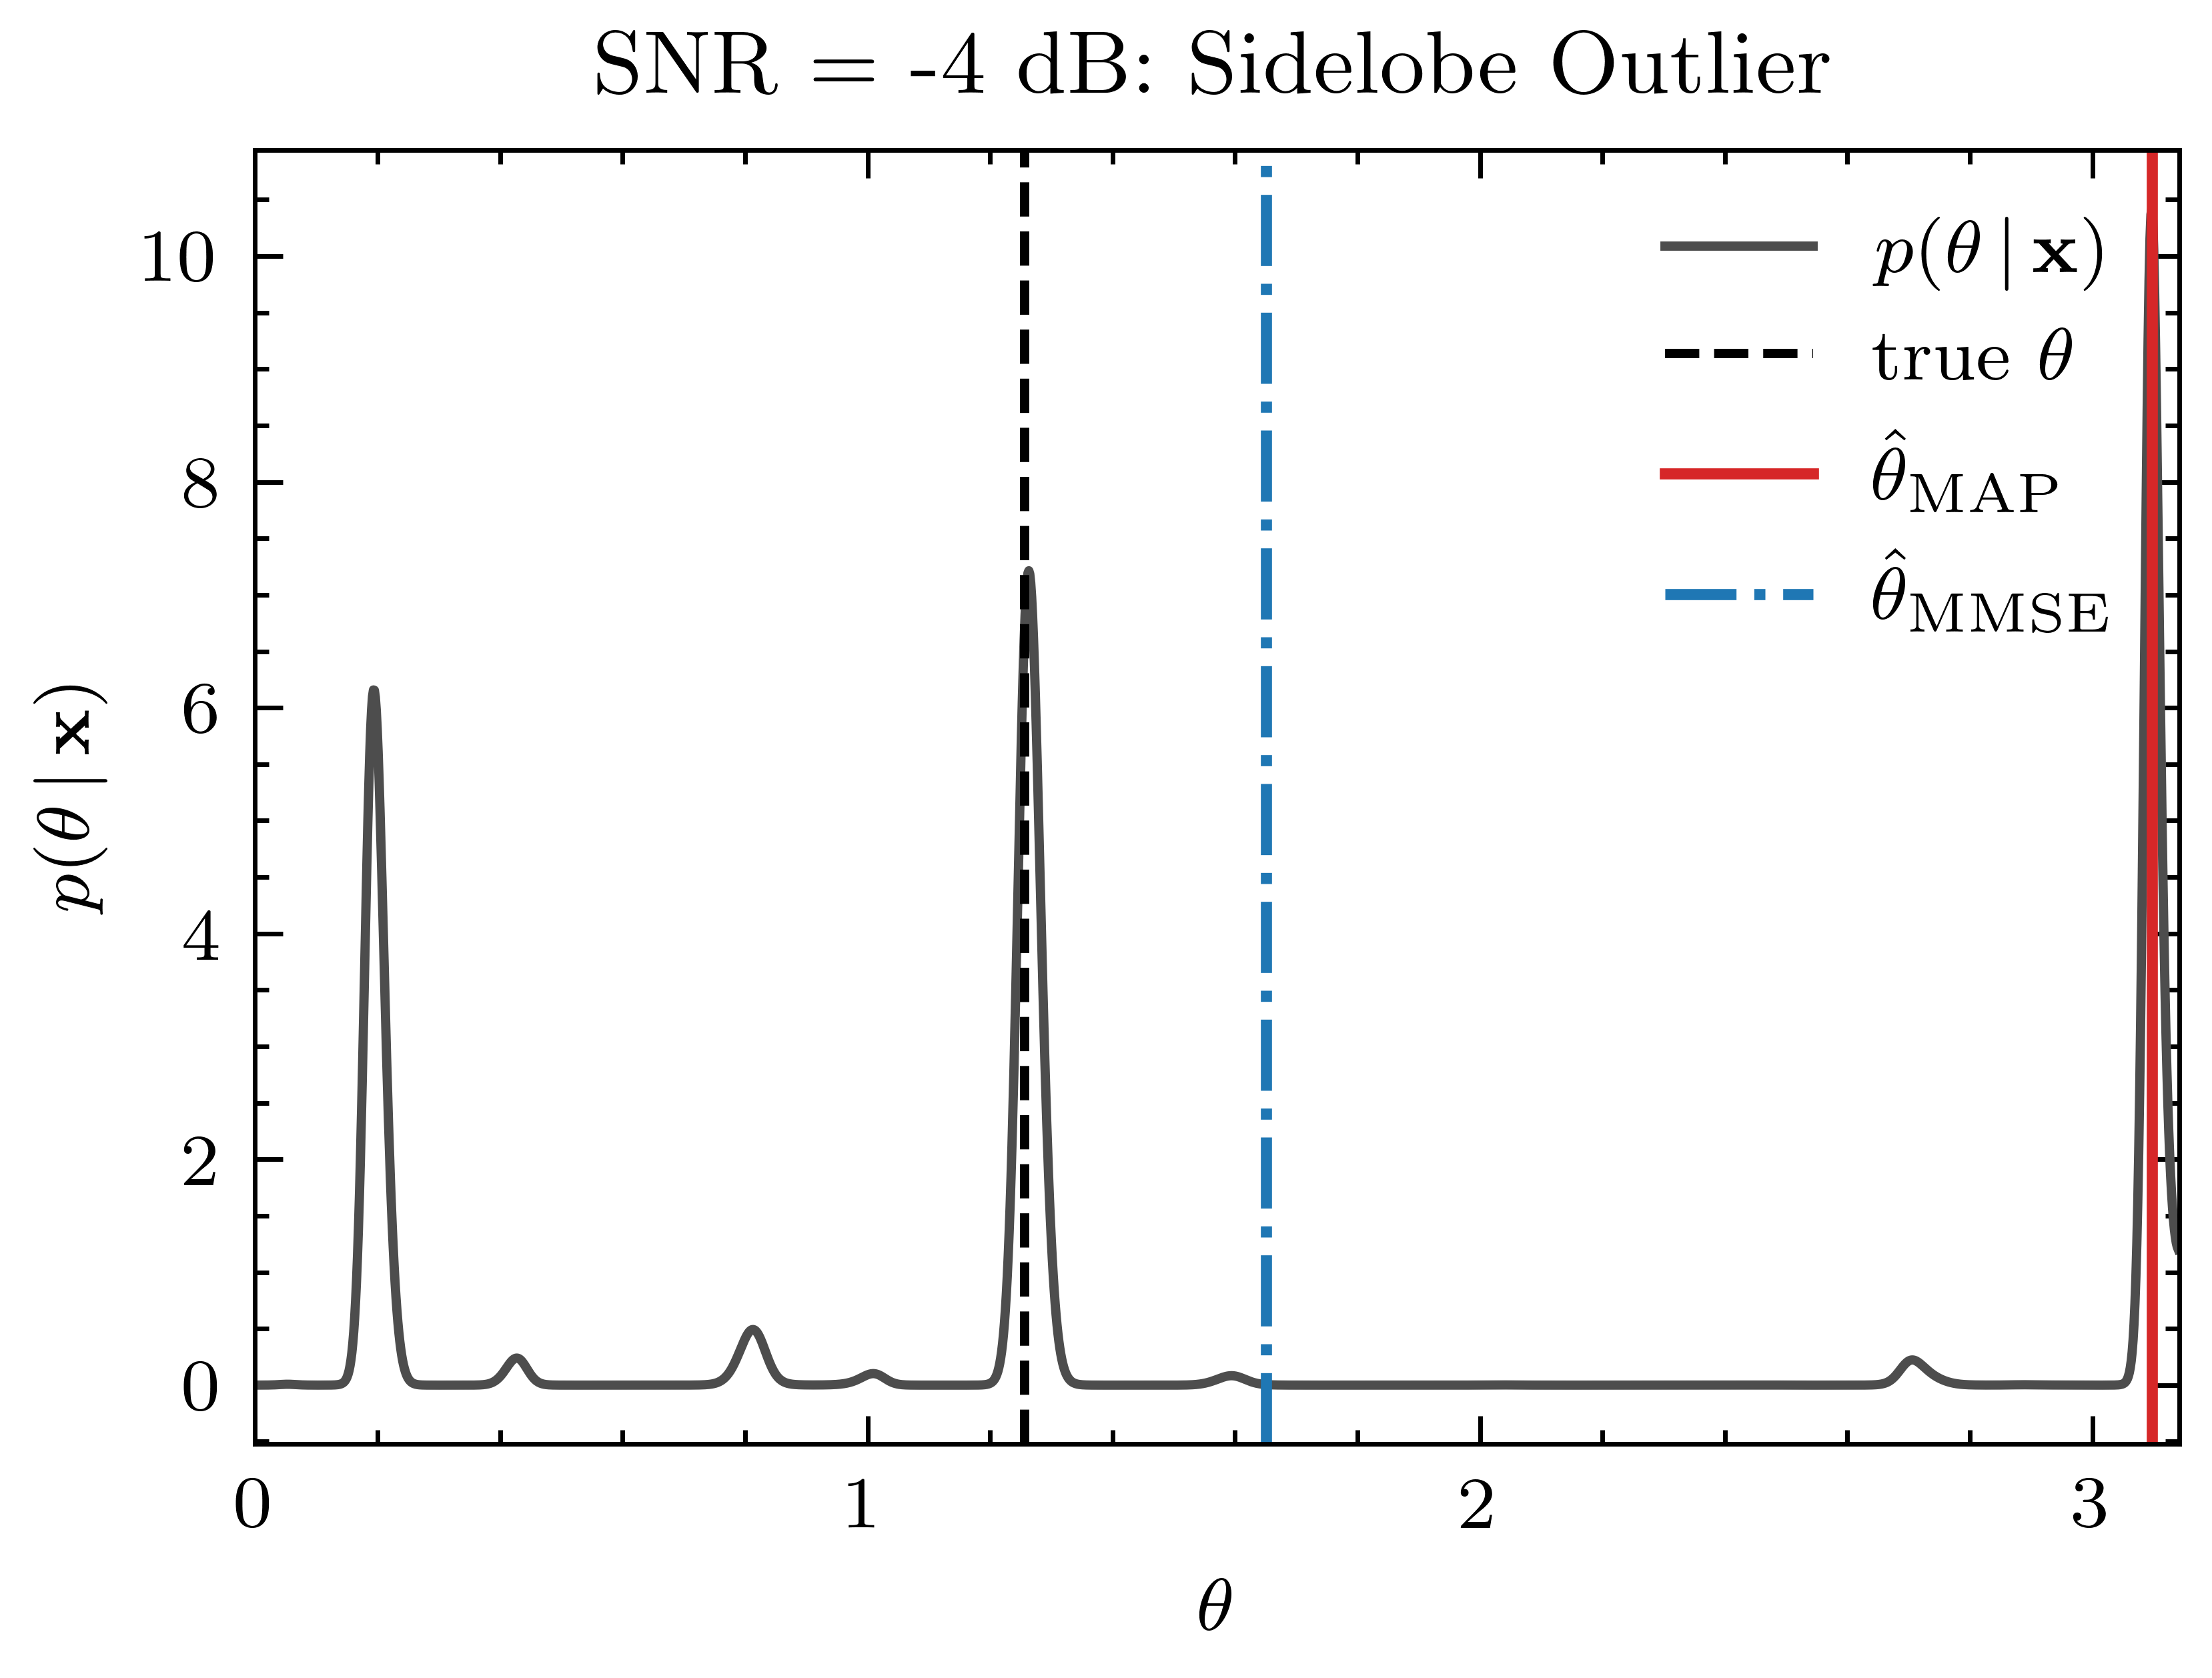

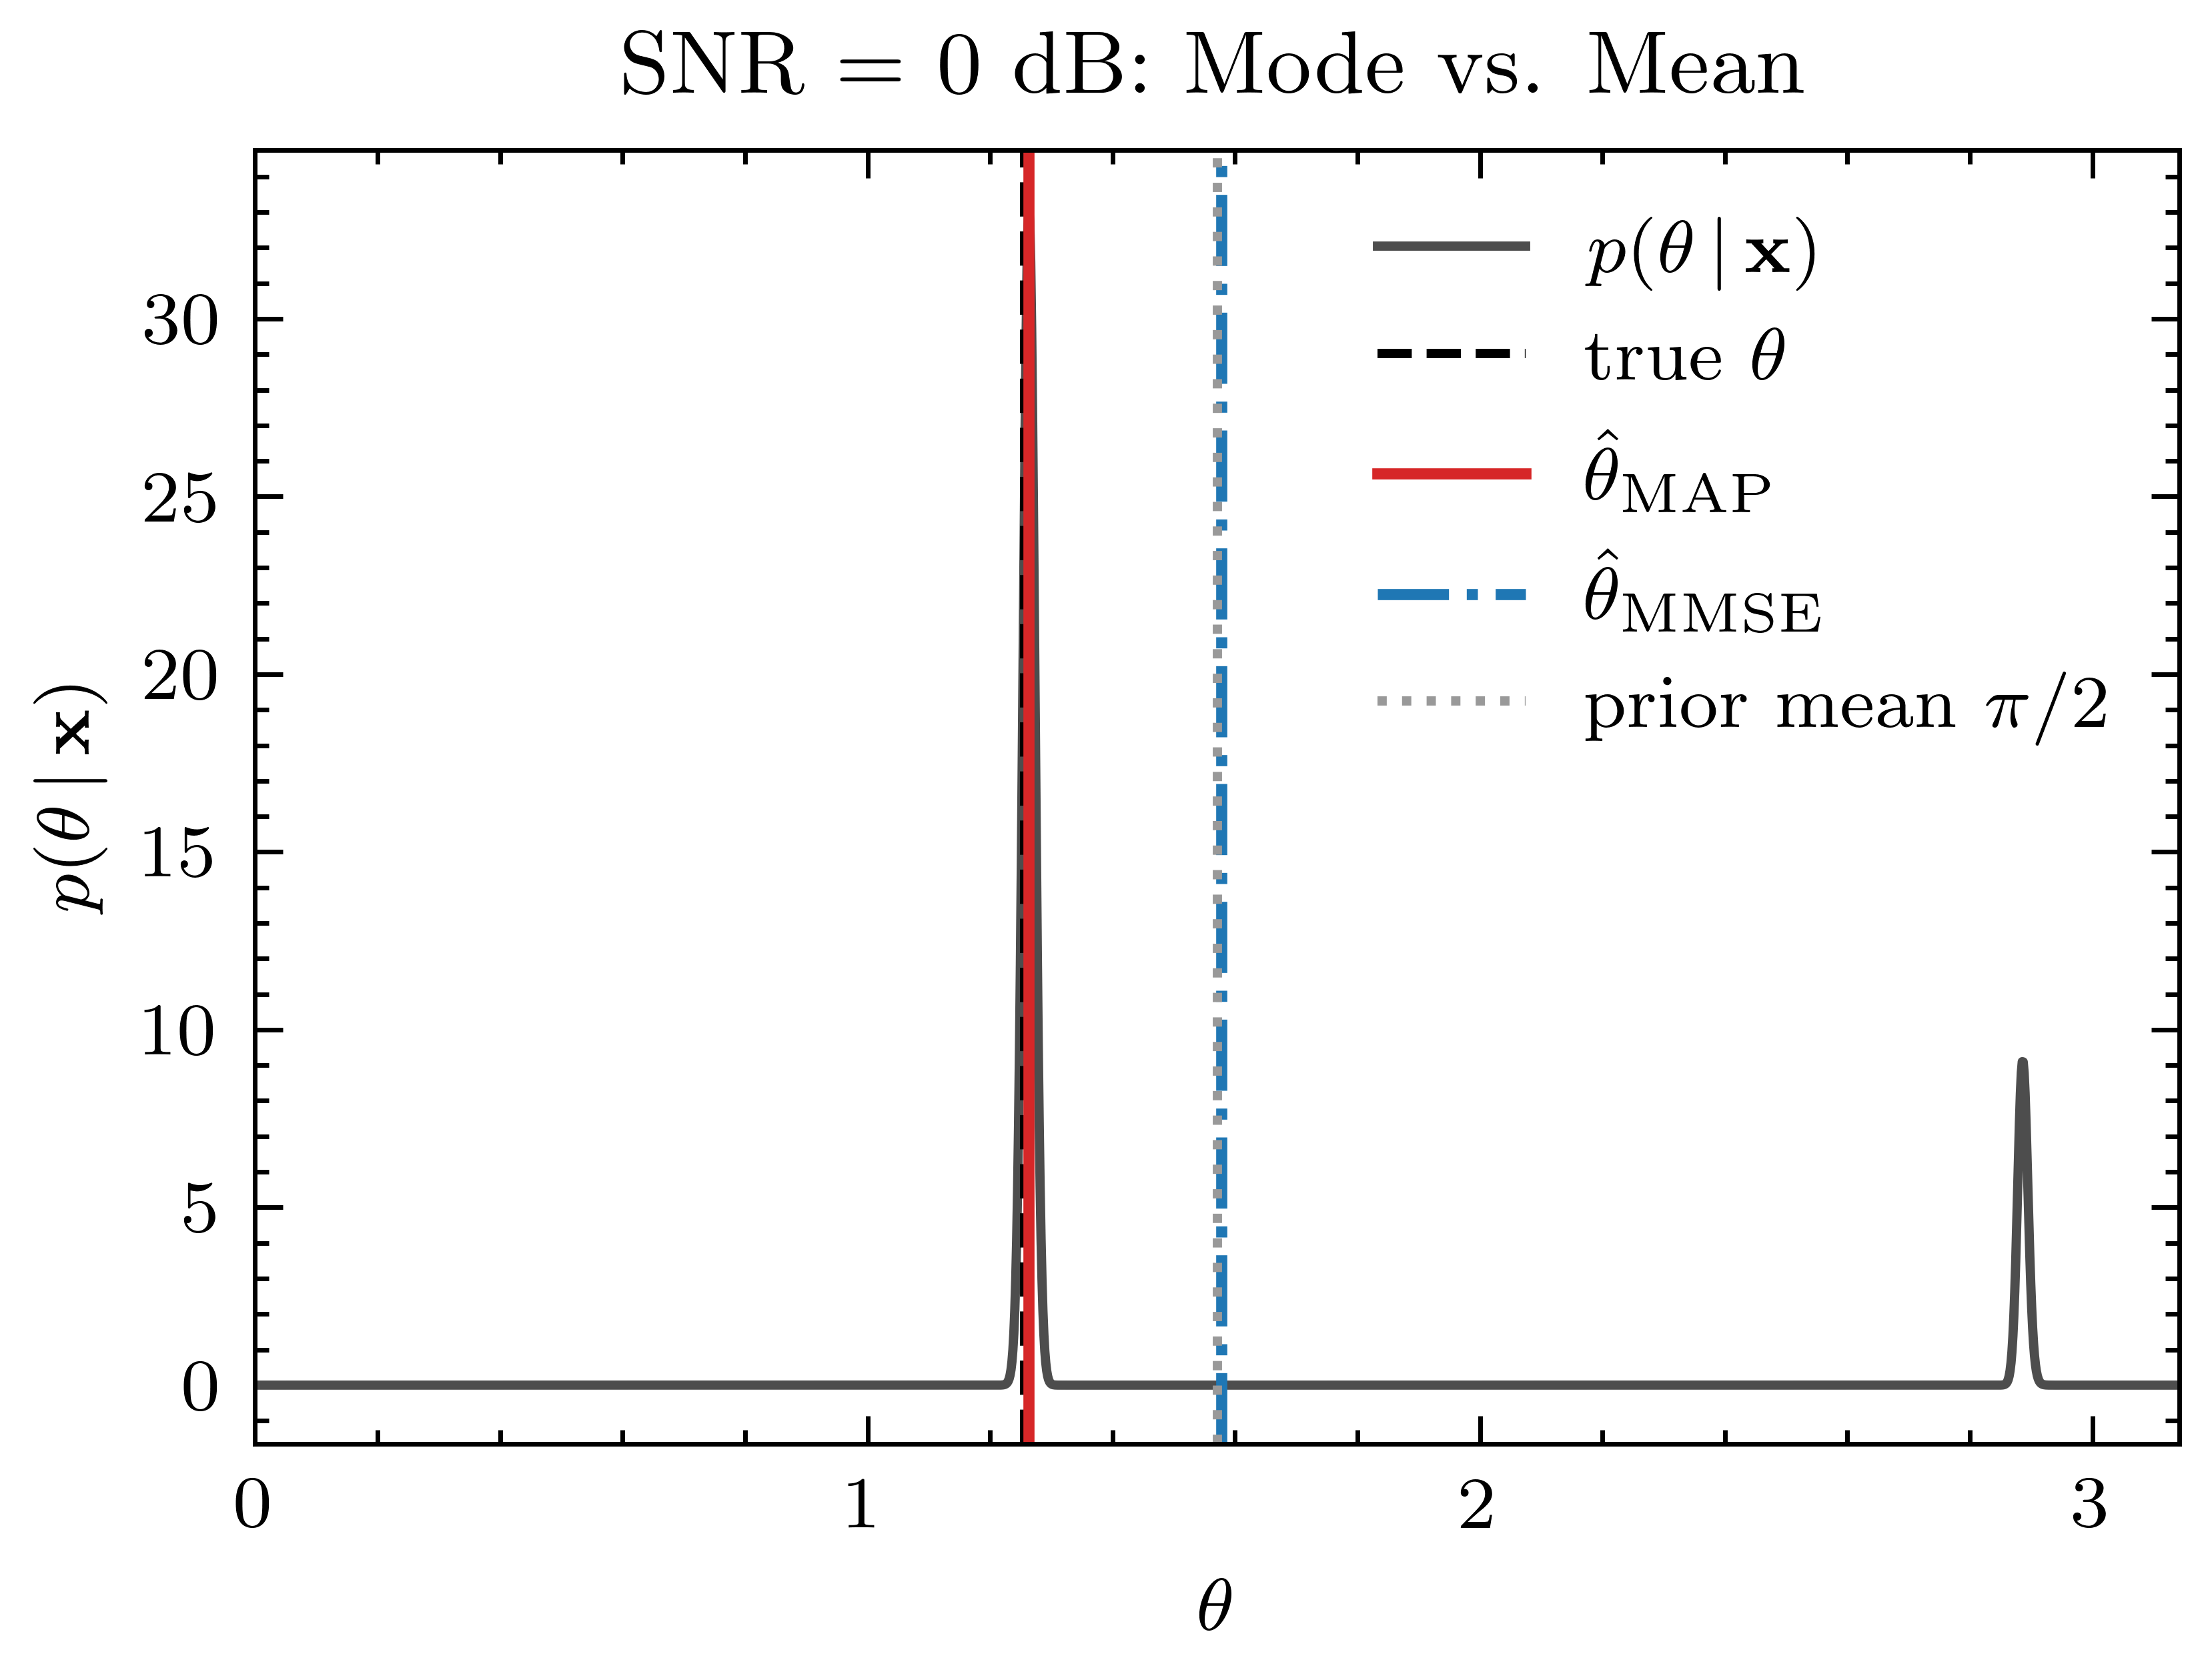

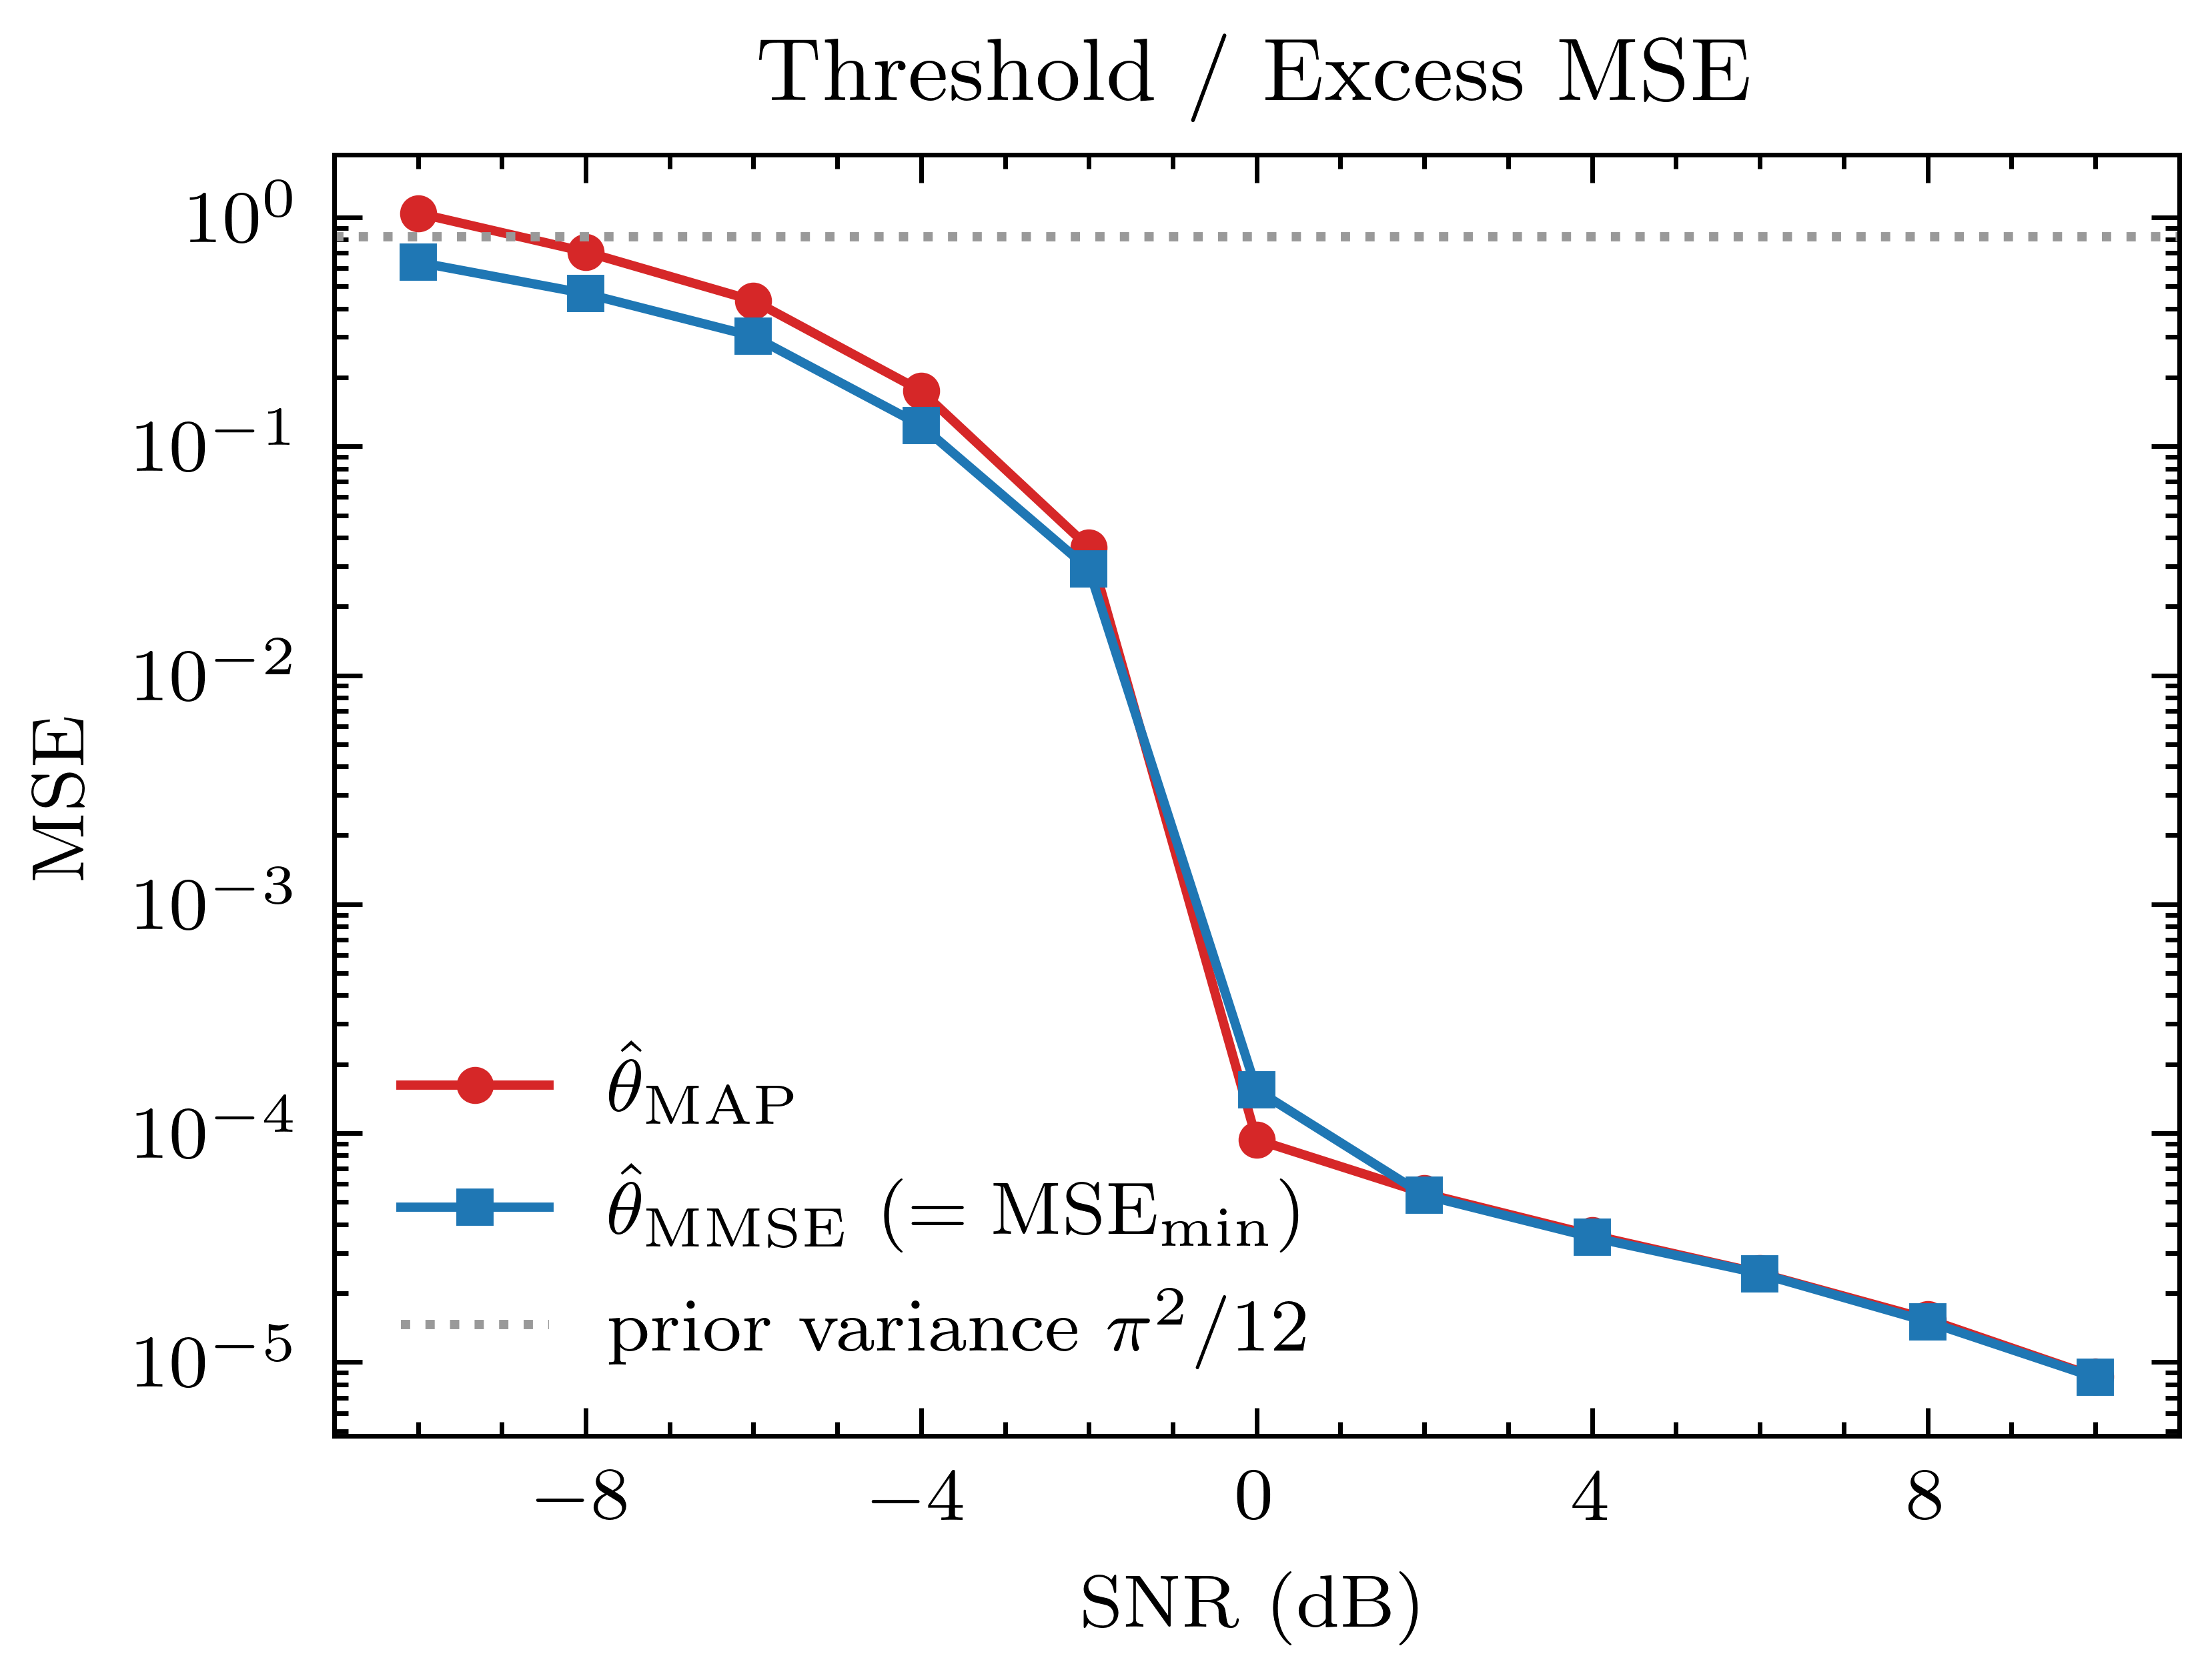

In [2]:
# %% [1] Setup: constants and a dense grid strictly inside (0, pi)
import math, torch
import matplotlib.pyplot as plt

torch.set_default_dtype(torch.float64)
N = 32
n = torch.arange(1.0, N + 1.0)                      # n = 1,...,N
G = 2048
phi = torch.linspace(0.0, math.pi, G + 2)[1:-1]     # open interval (0, pi)
S = torch.cos(phi[:, None] * n)                     # (G, N), rows = s(phi)
s2 = (S**2).sum(dim=1)                              # ||s(phi)||^2
plt.rcParams.update({"font.size": 8, "axes.grid": False})

# %% [2] Model + the two estimators
def sigma_of(snr_db):                               # gamma = 1/(2 sigma_v^2)
    return math.sqrt(0.5 / 10 ** (snr_db / 10.0))

def sample_data(theta, snr_db, seed):               # x = cos(n*theta) + v,  theta: (T,)
    g = torch.Generator().manual_seed(seed)
    v = sigma_of(snr_db) * torch.randn(theta.numel(), N, generator=g)
    return torch.cos(theta[:, None] * n) + v

def posterior(x, snr_db):                           # p(phi|x) on grid, trapezoid-normalized
    lp = (2.0 * x @ S.T - s2) / (2.0 * sigma_of(snr_db) ** 2)
    p = torch.exp(lp - lp.max(dim=1, keepdim=True).values)
    return p / torch.trapezoid(p, phi, dim=1)[:, None]
    ##min --> max, trapezoid-normalized

def theta_mmse(x, snr_db):                          # Eq. (mmse) by quadrature
    return torch.trapezoid(phi * posterior(x, snr_db), phi, dim=1)

def H_fun(t, x):                                    # Eq. (stationary)
    nt = t[:, None] * n
    return (n * torch.sin(nt) * (x - torch.cos(nt))).sum(dim=1)

def D_fun(t, x):                                    # Eq. (curvature)
    nt = t[:, None] * n
    return (n**2 * (x * torch.cos(nt) - torch.cos(2.0 * nt))).sum(dim=1)

def theta_map(x, iters=6):                          # Eq. (grid) + safeguarded Eq. (newton)
    t = phi[(s2 - 2.0 * x @ S.T).argmin(dim=1)]
    for _ in range(iters):
        Hv, Dv = H_fun(t, x), D_fun(t, x)
        cand = t - Hv / Dv
        ok = (Dv > 0) & (cand > 0.0) & (cand < math.pi)
        t = torch.where(ok, cand, t)
    return t

# %% [3] Panel (a): low SNR -> MAP locks onto a sidelobe
snr_a, th_a = -4.0, 0.40 * math.pi
X = sample_data(torch.full((2000,), th_a), snr_a, seed=1)
m = theta_map(X)
i = (m - th_a).abs().argmax()  # most severe outlier in the batch
x_a = X[i:i+1]
map_a, mmse_a = m[i].item(), theta_mmse(x_a, snr_a).item()
post_a = posterior(x_a, snr_a)[0]
print(f"(a) true={th_a:.4f}  MAP={map_a:.4f}  MMSE={mmse_a:.4f}")

# %% [4] Panel (b): correct main lobe, but posterior mean != mode
snr_b, th_b = 0.0, 0.40 * math.pi
X = sample_data(torch.full((2000,), th_b), snr_b, seed=2)
m, mm = theta_map(X), theta_mmse(X, snr_b)
hit = (m - th_b).abs() < 0.5 * math.pi / N  # main lobe correctly resolved
gap = torch.where(hit, (mm - m).abs(), torch.zeros_like(m))
i = gap.argmax()
x_b = X[i:i+1]
map_b, mmse_b = m[i].item(), mm[i].item()
post_b = posterior(x_b, snr_b)[0]
print(f"(b) true={th_b:.4f}  MAP={map_b:.4f}  MMSE={mmse_b:.4f}  gap={gap[i].item():.4f}")

# %% [5] Panel (c): Monte-Carlo MSE vs SNR, theta ~ U(0, pi)
snr_grid = torch.arange(-10.0, 10.1, 2.0)
T = 2000
mse_map, mse_mmse = [], []
for k, s_db in enumerate(snr_grid.tolist()):
    th = math.pi * torch.rand(T, generator=torch.Generator().manual_seed(500 + k))
    ##T=2000 times true theta
    x = sample_data(th, s_db, seed=900 + k)
    mse_map.append(((theta_map(x) - th) ** 2).mean().item())
    mse_mmse.append(((theta_mmse(x, s_db) - th) ** 2).mean().item())
    print(f"SNR {s_db:+5.1f} dB   MAP {mse_map[-1]:.3e}   MMSE {mse_mmse[-1]:.3e}")

# %% [6] Assemble and save the figure
import math
import torch
import matplotlib as mpl
import matplotlib.pyplot as plt
import scienceplots
from matplotlib.ticker import MultipleLocator

# -------------------------------------------------------------------------
# 全局学术样式配置 (SciencePlots + IEEE 规范)
# -------------------------------------------------------------------------
plt.style.use(['science', 'ieee'])
mpl.rcParams['font.serif'] = ['Times New Roman']
mpl.rcParams['figure.dpi'] = 1000
mpl.rcParams['axes.unicode_minus'] = False

# 定义符合 IEEE 单栏论文的标准尺寸 (通常宽度在 3.3 到 3.5 英寸左右)
FIG_SIZE = (3.3, 2.5) 

# -------------------------------------------------------------------------
# 图 (a): 旁瓣异常锁定 (Sidelobe Outlier)
# -------------------------------------------------------------------------
fig_a, ax_a = plt.subplots(figsize=FIG_SIZE, constrained_layout=True)

ax_a.plot(phi.numpy(), post_a.numpy(), color="0.3", label=r"$p(\theta\,|\,\mathbf{x})$")
ax_a.axvline(th_a, ls="--", c="k", lw=1, label=r"true $\theta$")
ax_a.axvline(map_a, c="tab:red", lw=1.2, label=r"$\hat\theta_{\mathrm{MAP}}$")
ax_a.axvline(mmse_a, c="tab:blue", ls="-.", lw=1.2, label=r"$\hat\theta_{\mathrm{MMSE}}$")

ax_a.set(xlabel=r"$\theta$", ylabel=r"$p(\theta\,|\,\mathbf{x})$",
         title=f"SNR = {snr_a:g} dB: Sidelobe Outlier", xlim=(0, math.pi))

# 使用 MultipleLocator 设置 x 轴主刻度间隔为 1.0
ax_a.xaxis.set_major_locator(MultipleLocator(1.0))
ax_a.legend(loc="upper right")
plt.show()
#fig_a.savefig("fig_map_vs_mmse_a.pdf")
#plt.close(fig_a)

# -------------------------------------------------------------------------
# 图 (b): 众数 vs 均值 (Mode vs. Mean)
# -------------------------------------------------------------------------
fig_b, ax_b = plt.subplots(figsize=FIG_SIZE, constrained_layout=True)

ax_b.plot(phi.numpy(), post_b.numpy(), color="0.3", label=r"$p(\theta\,|\,\mathbf{x})$")
ax_b.axvline(th_b, ls="--", c="k", lw=1, label=r"true $\theta$")  # 已修正为 th_b
ax_b.axvline(map_b, c="tab:red", lw=1.2, label=r"$\hat\theta_{\mathrm{MAP}}$")
ax_b.axvline(mmse_b, c="tab:blue", ls="-.", lw=1.2, label=r"$\hat\theta_{\mathrm{MMSE}}$")
ax_b.axvline(math.pi / 2, ls=":", c="0.6", lw=1, label=r"prior mean $\pi/2$")

ax_b.set(xlabel=r"$\theta$", ylabel=r"$p(\theta\,|\,\mathbf{x})$",
         title=f"SNR = {snr_b:g} dB: Mode vs. Mean", xlim=(0, math.pi))

ax_b.xaxis.set_major_locator(MultipleLocator(1.0))
ax_b.legend(loc="upper right")
plt.show()
#fig_b.savefig("fig_map_vs_mmse_b.pdf")
#plt.close(fig_b)

# -------------------------------------------------------------------------
# 图 (c): 均方误差性能曲线 (Threshold / Excess MSE)
# -------------------------------------------------------------------------
fig_c, ax_c = plt.subplots(figsize=FIG_SIZE, constrained_layout=True)

ax_c.semilogy(snr_grid.numpy(), mse_map, "o-", c="tab:red", lw=1, markersize=3,
             label=r"$\hat\theta_{\mathrm{MAP}}$")
ax_c.semilogy(snr_grid.numpy(), mse_mmse, "s-", c="tab:blue", lw=1, markersize=3,
             label=r"$\hat\theta_{\mathrm{MMSE}}\ (=\mathrm{MSE}_{\min})$")
ax_c.axhline(math.pi**2 / 12, ls=":", c="0.6", lw=1,
            label=r"prior variance $\pi^{2}/12$")

ax_c.set(xlabel="SNR (dB)", ylabel="MSE", title="Threshold / Excess MSE")

# 设置 SNR 轴的刻度间隔为 4.0 dB
ax_c.xaxis.set_major_locator(MultipleLocator(4.0))
ax_c.legend(loc="lower left")
plt.show()
#fig_c.savefig("fig_map_vs_mmse_c.pdf")

In [3]:
# %% [3b] Noise-enhanced estimate for the panel-(a) realization, Eq. (theta_ne)
# Illustrative choice q(z) = N(0, sigma_z^2 I); the optimal design of q is the
# subject of the following sections.
sigma_z = 1.0 * sigma_of(snr_a)                     # artificial-noise level (tunable)
L = 4000                                            # Monte-Carlo samples for E_z[.]
gz = torch.Generator().manual_seed(7)
Z = sigma_z * torch.randn(L, N, generator=gz)
##For N samples generating L=4000 z_k
th_pert = theta_map(x_a + Z)                        # MAP estimates of perturbed data
ne_a = th_pert.mean().item()
print(f"(a) NE={ne_a:.4f}  (sigma_z = sigma_v, L={L}, "
      f"MC-SE={th_pert.std().item()/math.sqrt(L):.4f})")
print(f"    |MAP-true|={abs(map_a-th_a):.3f}   |NE-true|={abs(ne_a-th_a):.3f}   "
      f"|NE-MMSE|={abs(ne_a-mmse_a):.3f}")

# sensitivity of the NE estimate to the artificial-noise level
for c in [0.5, 1.0, 1.5, 2.0]:
    gz = torch.Generator().manual_seed(7)
    tp = theta_map(x_a + c * sigma_of(snr_a) * torch.randn(L, N, generator=gz))
    print(f"    sigma_z={c:3.1f}*sigma_v  ->  NE={tp.mean().item():.4f}")

(a) NE=1.5420  (sigma_z = sigma_v, L=4000, MC-SE=0.0179)
    |MAP-true|=1.840   |NE-true|=0.285   |NE-MMSE|=0.109
    sigma_z=0.5*sigma_v  ->  NE=1.6829
    sigma_z=1.0*sigma_v  ->  NE=1.5420
    sigma_z=1.5*sigma_v  ->  NE=1.5145
    sigma_z=2.0*sigma_v  ->  NE=1.5207


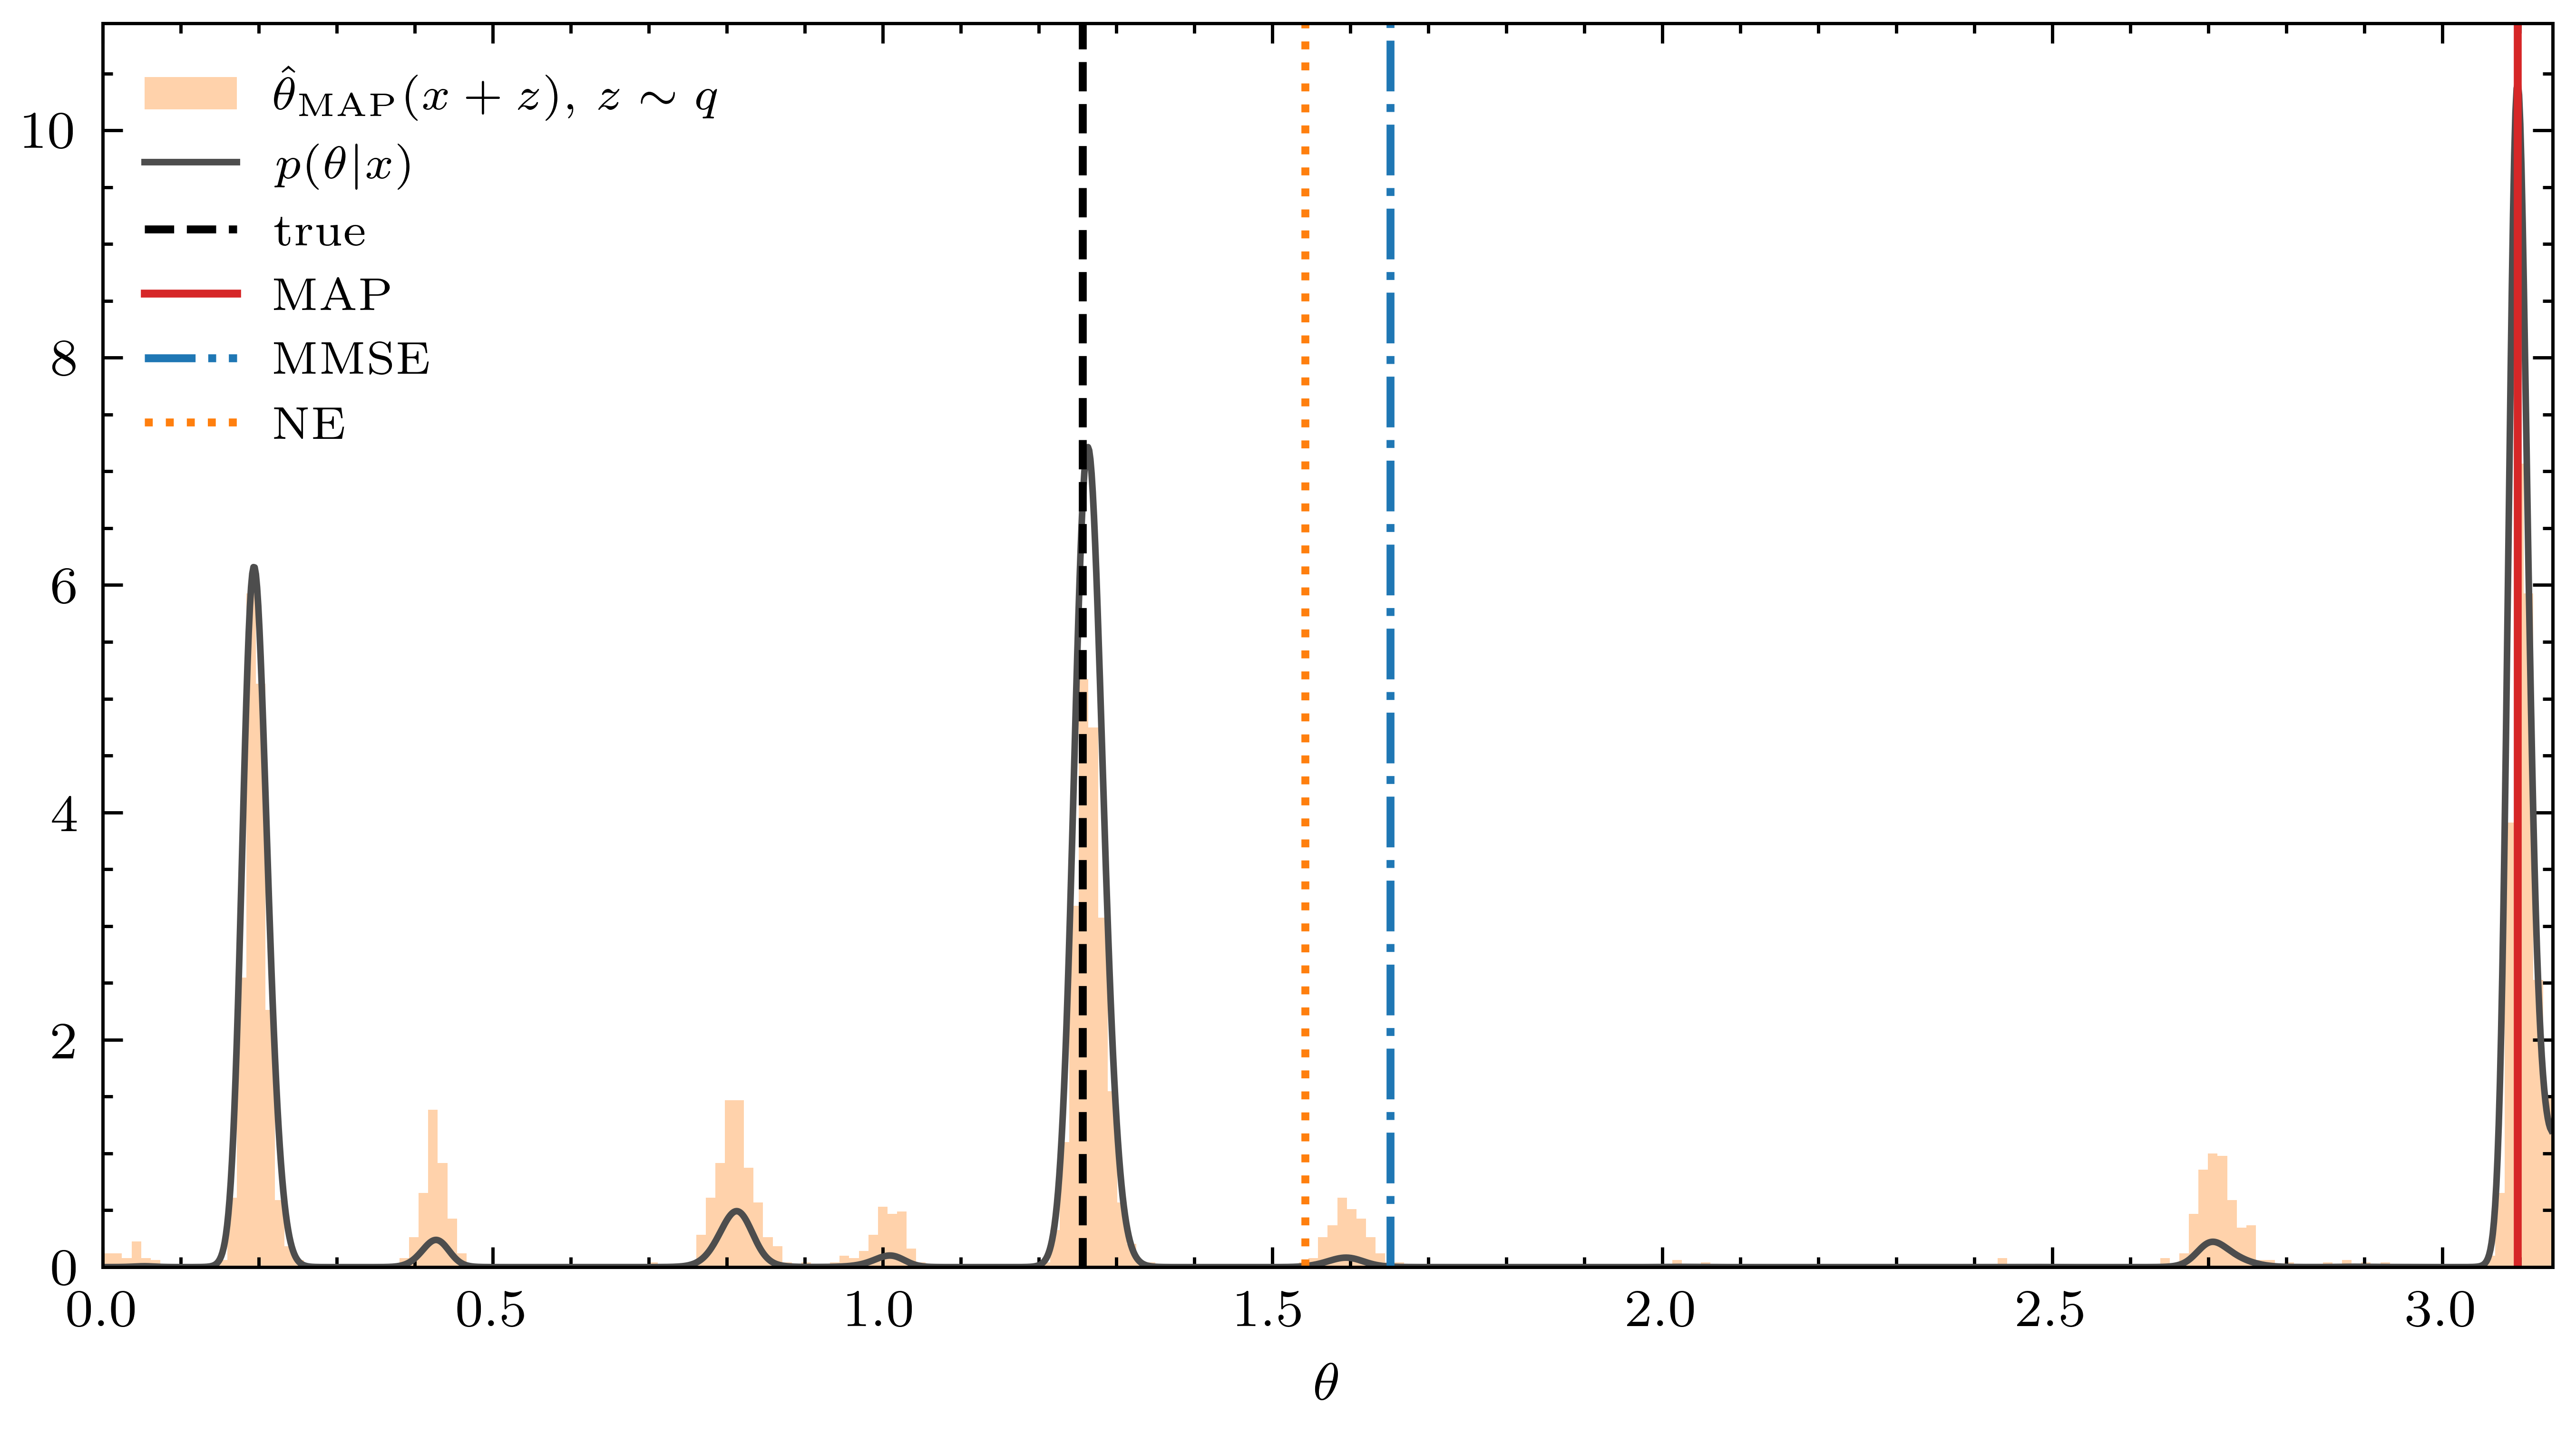

In [4]:
# %% [3c] Diagnostic (not for the paper): what the NE estimator averages.
# The distribution of theta_MAP(x+z) hedges across the posterior lobes, so its
# mean (= theta_NE) mimics the posterior-mean hedging of theta_MMSE.
fig_d, ax_d = plt.subplots(figsize=(5.4, 3.0), constrained_layout=True)
ax_d.hist(th_pert.numpy(), bins=256, range=(0.0, math.pi), density=True,
          color="tab:orange", alpha=0.35,
          label=r"$\hat\theta_{\mathrm{MAP}}(x+z)$, $z\sim q$")
ax_d.plot(phi.numpy(), post_a.numpy(), color="0.3", label=r"$p(\theta|x)$")
for val, c, ls, lab in [(th_a, "k", "--", "true"), (map_a, "tab:red", "-", "MAP"),
                        (mmse_a, "tab:blue", "-.", "MMSE"),
                        (ne_a, "tab:orange", ":", "NE")]:
    ax_d.axvline(val, c=c, ls=ls, lw=1.2, label=lab)
ax_d.set(xlabel=r"$\theta$", xlim=(0, math.pi))
ax_d.legend(fontsize=7)
plt.show()

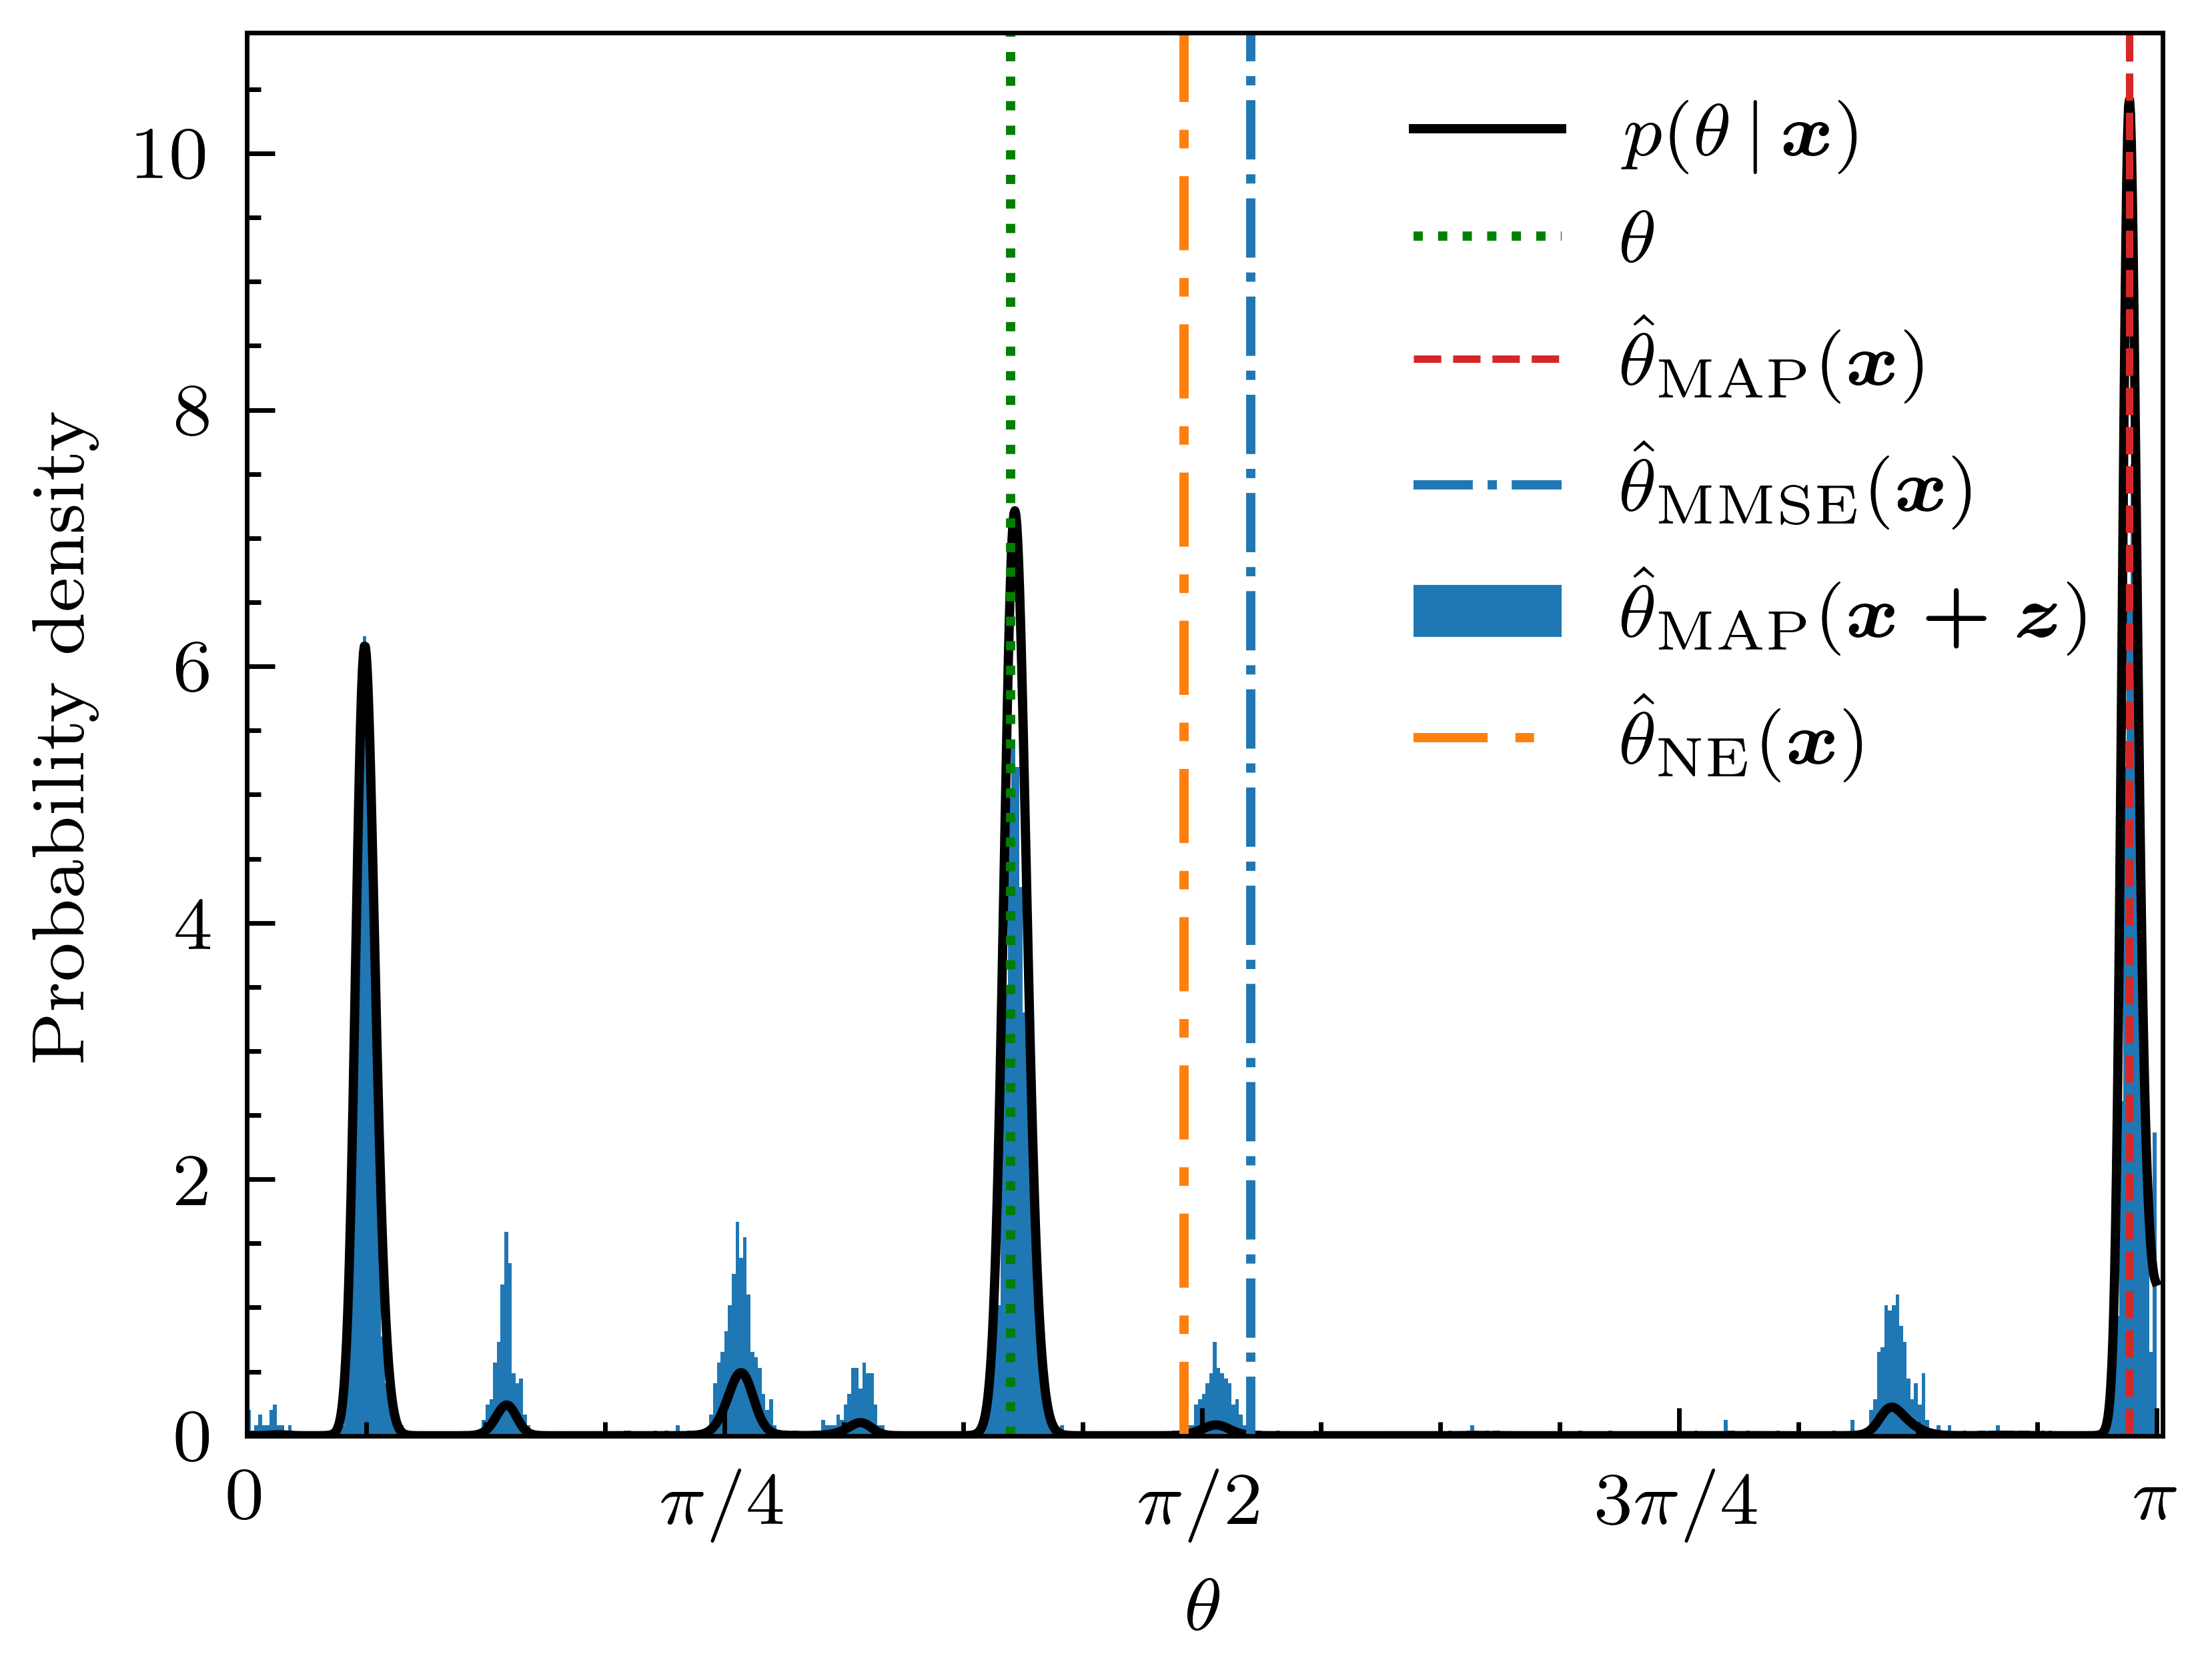

In [5]:
import math
import torch
import matplotlib as mpl
import matplotlib.pyplot as plt
import scienceplots

# -------------------------------------------------------------------------
# 全局学术样式配置 (SciencePlots + IEEE 规范)
# -------------------------------------------------------------------------
plt.style.use(['science', 'ieee'])
mpl.rcParams['font.serif'] = ['Times New Roman']
mpl.rcParams['figure.dpi'] = 1000
mpl.rcParams['axes.unicode_minus'] = False

# 如果开启了 usetex，确保导入 amsmath 以支持 \boldsymbol
mpl.rcParams['text.latex.preamble'] = r'\usepackage{amsmath}'

# 定义符合 IEEE 单栏论文的标准尺寸
FIG_SIZE = (3.3, 2.5) 
fig_a, ax_a = plt.subplots(figsize=FIG_SIZE, constrained_layout=True)

# 显式关闭网格线
ax_a.grid(False)
ax_a.tick_params(
    axis="both",
    which="both",
    top=False,
    right=False
)
# 绘制后验概率密度
ax_a.plot(phi.numpy(), post_a.numpy(),ls="-", color="k",label=r"$p(\theta\,|\,\boldsymbol{x})$")

# 绘制四条垂直线
ax_a.axvline(th_a, ls=":", c="g", lw=1, label=r"$\theta$")

ax_a.axvline(map_a, c="tab:red", ls="--", lw=0.8, label=r"$\hat\theta_{\mathrm{MAP}}(\boldsymbol{x})$")

ax_a.axvline(mmse_a, c="tab:blue", ls="-.", lw=1, label=r"$\hat\theta_{\mathrm{MMSE}}(\boldsymbol{x})$")

# 噪声增强估计 (noise-enhanced estimate, Eq. (theta_ne))
ax_a.hist(th_pert.numpy(), bins=512, range=(0.0, math.pi), density=True,
          color="tab:blue", label=r"$\hat\theta_{\mathrm{MAP}}(\boldsymbol{x+z})$")
ax_a.axvline(ne_a, c="tab:orange", ls=(0, (8, 3, 2, 3)), lw=1, label=r"$\hat\theta_{\mathrm{NE}}(\boldsymbol{x})$")
# -------------------------------------------------------------------------

# 坐标轴与刻度设置
ax_a.set(xlabel=r"$\theta$", ylabel=r"Probability density", xlim=(0, math.pi+0.01))

pi_ticks_4 = [0, math.pi/4, math.pi/2, 3*math.pi/4, math.pi]
pi_labels_4 = [r'$0$', r'$\pi/4$', r'$\pi/2$', r'$3\pi/4$', r'$\pi$']
ax_a.set_xticks(pi_ticks_4)
ax_a.set_xticklabels(pi_labels_4)
ax_a.legend(loc="upper right")
plt.show()
fig_a.savefig("Fig1.pdf", dpi=1000)   # was: D:/加权最小二乘/Fig1.pdf
fig_a.savefig("Fig1.png", dpi=300)    # quick-look raster copy

K = 4,  beta = 4,  sigma_v = 1.1207,  ||z_k||_2 <= 4.4828
operating point: SNR = -4 dB,  Delta = 2*pi/N = 0.1963
NLS/MAP MSE :  train 1.6947e-01   val 1.8296e-01
MMSE    MSE :                       val 1.2675e-01   (lower bound)
  alpha = 0 (NLS)   L = 1.6947e-01
  alpha =     0.5   L = 1.5619e-01
  alpha =       1   L = 1.4570e-01
  alpha =     1.5   L = 1.4140e-01
  alpha =       2   L = 1.3839e-01
  alpha =     2.5   L = 1.4212e-01
  alpha =       3   L = 1.5770e-01
  alpha =     3.5   L = 1.7359e-01
  alpha =       4   L = 1.9077e-01
selected Z(0):  alpha* = 2,  L(Z(0)) = 1.3839e-01
  iter  1:  L = 1.3523e-01   eta = 6.50e-01
  iter  5:  L = 1.3523e-01   eta = 1.42e-05
  iter 10:  L = 1.3523e-01   eta = 5.14e-08
  iter 12: no descent step found -- stop
refined bank Z(T):  L = 1.3523e-01   (NLS baseline 1.6947e-01  ->  training gain 20.2%)
||z_k||_2 / sigma_v = ['2.01', '1.87', '2.09', '2.03']
T_t = -4.50   T_mc = -17.07  (n10 = 43, n01 = 404)   g = 18.97%
validation gate PASSED  ->

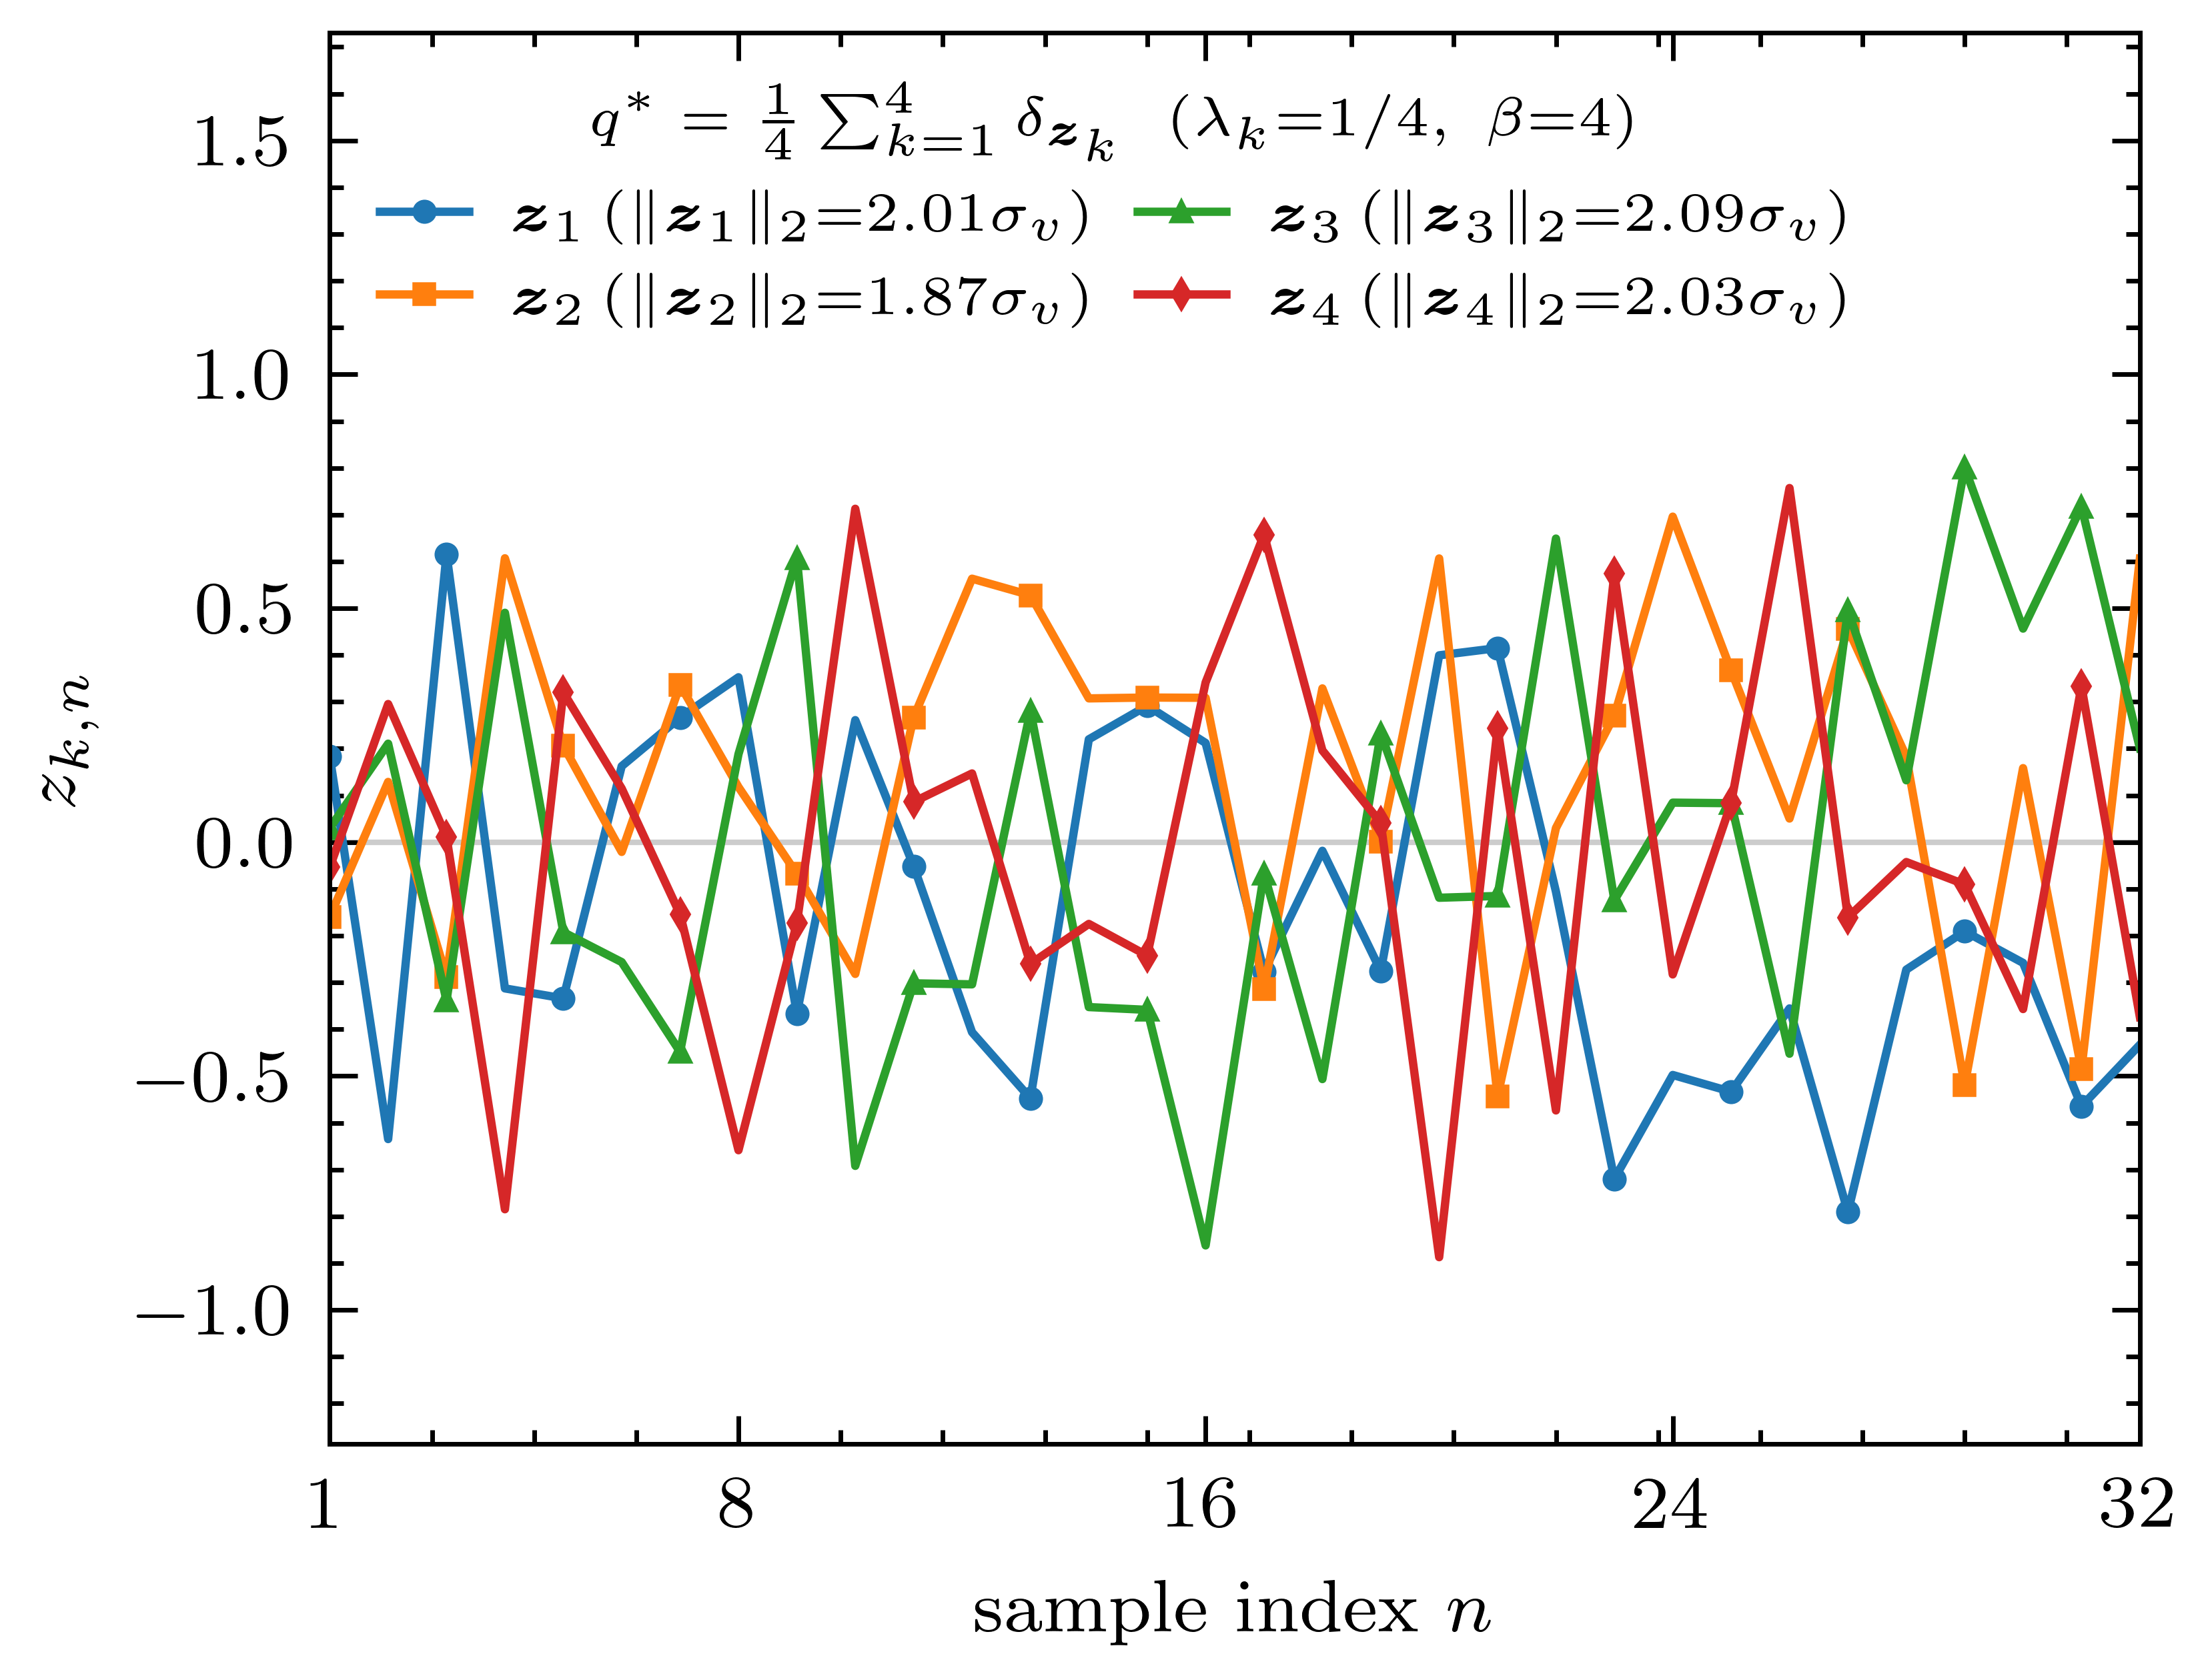

q*: K = 4 atoms with uniform weights 1/K;  theta_ANE(x_a) = 1.4557  (true 1.2566, MAP 3.0968)


In [6]:
# %% [7] ANE building blocks (Alg. 1): estimator, empirical risk, gradient, projections
# Finite-particle parameterization of the optimal measure q* (Eq. (ane)):
#   q_Z = (1/K) sum_k delta_{z_k},  lambda_k = 1/K,  Z = [z_1,...,z_K]^T in R^{K x N}
K      = 4                                # number of support points of q*
beta   = 4.0                              # dither-to-noise cap: ||z_k||_2 <= beta*sigma_v
sigv   = sigma_of(snr_a)                  # operating noise level (panel (a): SNR = -4 dB)
radius = beta * sigv

def grad_theta_map(t, x):
    """Implicit-function gradient (Eq. (ift)):
       d theta_MAP / d x_n = -n sin(n theta_MAP) / D(theta_MAP, x);
       D is already available from the Newton recursion."""
    D = D_fun(t, x)
    D = torch.where(D >= 0, D.clamp(min=1e-9), D.clamp(max=-1e-9))     # safeguard
    return -(n * torch.sin(t[:, None] * n)) / D[:, None]               # (B, N)

def ane_forward(Xb, THb, Z):
    """theta_ANE (Eq. (ane)) and empirical risk L(Z) (Eq. (erm)) on pairs (Xb, THb)."""
    M  = Xb.shape[0]
    Xp = (Xb.unsqueeze(0) + Z.unsqueeze(1)).reshape(-1, N)             # rows: x_m + z_k
    t  = theta_map(Xp).view(Z.shape[0], M)                             # K parallel NLS solves
    r  = t.mean(dim=0) - THb                                           # fused residuals
    return (r ** 2).mean().item(), t, Xp, r

def ane_grad(Z, t, Xp, r):
    """Gradient of L w.r.t. each z_k (Eq. (grad)); reuses the forward-pass quantities."""
    Kc, M = t.shape
    g = grad_theta_map(t.reshape(-1), Xp).view(Kc, M, N)
    return (2.0 / (M * Kc)) * (r.view(1, M, 1) * g).sum(dim=1)         # (K, N)

def proj_S(Z):                              # centroid subspace:  sum_k z_k = 0
    return Z - Z.mean(dim=0, keepdim=True)

def proj_B(Z, r=None):                      # per-atom l2 ball of radius beta*sigma_v
    r = radius if r is None else r
    nrm = Z.norm(dim=1, keepdim=True).clamp(min=1e-12)
    return Z * torch.clamp(r / nrm, max=1.0)

def proj_Omega(Z):                          # one POCS sweep (Eq. (omega))
    return proj_B(proj_S(Z))

print(f"K = {K},  beta = {beta:g},  sigma_v = {sigv:.4f},  ||z_k||_2 <= {radius:.4f}")

# %% [8] Offline training / validation pairs at the operating noise level sigma_v
M_tr, M_va = 2000, 4000
th_tr = math.pi * torch.rand(M_tr, generator=torch.Generator().manual_seed(101))
X_tr  = sample_data(th_tr, snr_a, seed=102)
th_va = math.pi * torch.rand(M_va, generator=torch.Generator().manual_seed(201))
X_va  = sample_data(th_va, snr_a, seed=202)

mse_map_tr  = ((theta_map(X_tr) - th_tr) ** 2).mean().item()           # plain NLS baseline
mse_map_va  = ((theta_map(X_va) - th_va) ** 2).mean().item()
mse_mmse_va = ((theta_mmse(X_va, snr_a) - th_va) ** 2).mean().item()   # MSE_min reference
print(f"operating point: SNR = {snr_a:g} dB,  Delta = 2*pi/N = {2 * math.pi / N:.4f}")
print(f"NLS/MAP MSE :  train {mse_map_tr:.4e}   val {mse_map_va:.4e}")
print(f"MMSE    MSE :                       val {mse_mmse_va:.4e}   (lower bound)")

# %% [9] Algorithm 1, Phase 1: initialization by a coarse dither-to-noise scale search
gU = torch.Generator().manual_seed(11)
U  = torch.randn(K, N, generator=gU)
U  = U - U.mean(dim=0, keepdim=True)        # center:     sum_k u_k = 0
U  = U / U.norm(dim=1, keepdim=True)        # normalize:  ||u_k||_2 = 1

A_grid = [0.5, 1.0, 1.5, 2.0, 2.5, 3.0, 3.5, 4.0]        # candidate ratios alpha
cand   = [torch.zeros(K, N)] + [proj_Omega(a * sigv * U) for a in A_grid]
L_cand = [ane_forward(X_tr, th_tr, Zc)[0] for Zc in cand]
for lab, Lc in zip(["0 (NLS)"] + [f"{a:g}" for a in A_grid], L_cand):
    print(f"  alpha = {lab:>7s}   L = {Lc:.4e}")
i0    = int(torch.tensor(L_cand).argmin())
Z     = cand[i0].clone()
L_cur = L_cand[i0]
print(f"selected Z(0):  alpha* = {(['0'] + [f'{a:g}' for a in A_grid])[i0]},  "
      f"L(Z(0)) = {L_cur:.4e}")

# %% [10] Algorithm 1, Phase 2: monotone projected-gradient refinement of the bank
eta, eta_min, T_pg = 0.5, 1e-8, 40
L_hist = [L_cur]
for t_it in range(1, T_pg + 1):
    _, t_fw, Xp, r = ane_forward(X_tr, th_tr, Z)          # forward pass at Z(t-1)
    Gt   = ane_grad(Z, t_fw, Xp, r)                       # Eq. (grad)
    gmax = Gt.norm(dim=1).max().clamp(min=1e-12)          # ||G||_max
    accepted = False
    while eta >= eta_min:                                 # backtracking line search
        Z_try = proj_Omega(Z - (eta / gmax) * Gt)
        L_try = ane_forward(X_tr, th_tr, Z_try)[0]
        if L_try < L_cur:                                 # accept only strict descent
            accepted = True
            break
        eta *= 0.5
    if not accepted:
        print(f"  iter {t_it:2d}: no descent step found -- stop")
        break
    Z, L_cur, eta = Z_try, L_try, 1.3 * eta
    L_hist.append(L_cur)
    if t_it == 1 or t_it % 5 == 0:
        print(f"  iter {t_it:2d}:  L = {L_cur:.4e}   eta = {eta:.2e}")
print(f"refined bank Z(T):  L = {L_cur:.4e}   "
      f"(NLS baseline {mse_map_tr:.4e}  ->  training gain {100 * (1 - L_cur / mse_map_tr):.1f}%)")
print("||z_k||_2 / sigma_v =", [f"{v:.2f}" for v in (Z.norm(dim=1) / sigv).tolist()])

# %% [11] Algorithm 1, Phase 3: validation gate (paired t / McNemar + relative gain)
z_sig, delta_gain = 3.0, 0.02
Delta = 2.0 * math.pi / N                       # anomaly threshold (mainlobe width)

e0 = theta_map(X_va) - th_va                    # plain NLS errors  e_j^0
_, _, _, e = ane_forward(X_va, th_va, Z)        # ANE errors        e_j
d   = e ** 2 - e0 ** 2
T_t = d.mean().item() * math.sqrt(M_va) / d.std(unbiased=True).item()
n10 = int(((e0.abs() >  Delta) & (e.abs() <= Delta)).sum())     # anomalies removed
n01 = int(((e0.abs() <= Delta) & (e.abs() >  Delta)).sum())     # anomalies introduced
T_mc = (n10 - n01) / math.sqrt(max(n10 + n01, 1))
gain = 1.0 - (e ** 2).sum().item() / (e0 ** 2).sum().item()
print(f"T_t = {T_t:.2f}   T_mc = {T_mc:.2f}  (n10 = {n10}, n01 = {n01})   g = {100 * gain:.2f}%")

if (T_t < -z_sig or T_mc > z_sig) and gain >= delta_gain:
    Z_star = Z.clone()
    print("validation gate PASSED  ->  Z* = Z(T): learned bank activated")
else:
    Z_star = torch.zeros_like(Z)
    print("validation gate FAILED  ->  Z* = 0:   ANE reduces to the ordinary NLS")
print(f"val MSE:  NLS {mse_map_va:.4e}   ANE {(e ** 2).mean().item():.4e}   "
      f"MMSE {mse_mmse_va:.4e}")

# %% [12] Algorithm 1, Phase 4: online ANE estimate for the Fig.-1 realization x_a
th_k   = theta_map(x_a + Z_star)                # K parallel NLS solves (batched)
ane_a4 = th_k.mean().item()                     # uniform fusion (Eq. (ane))
print("individual solves theta_k :", [f"{v:.4f}" for v in th_k.tolist()])
print(f"theta_ANE (K = 4)         : {ane_a4:.4f}")
print(f"true theta                : {th_a:.4f}      (MAP {map_a:.4f},  MMSE {mmse_a:.4f})")
print(f"|MAP-true| = {abs(map_a - th_a):.4f}   |ANE-true| = {abs(ane_a4 - th_a):.4f}   "
      f"|MMSE-true| = {abs(mmse_a - th_a):.4f}")

# %% [13] Fig. 2: the optimal discrete noise density q* (K = 4), support points z_1,...,z_4
import math
import torch
import matplotlib as mpl
import matplotlib.pyplot as plt
import scienceplots

plt.style.use(['science', 'ieee'])
mpl.rcParams['font.serif'] = ['Times New Roman']
mpl.rcParams['figure.dpi'] = 1000
mpl.rcParams['axes.unicode_minus'] = False
mpl.rcParams['text.latex.preamble'] = r'\usepackage{amsmath}'

FIG_SIZE = (3.3, 2.5)
fig2, ax2 = plt.subplots(figsize=FIG_SIZE, constrained_layout=True)
ax2.grid(False)
ax2.axhline(0.0, color="0.8", lw=0.6, zorder=0)

idx   = torch.arange(1, N + 1).numpy()
cols  = ["tab:blue", "tab:orange", "tab:green", "tab:red"]
marks = ["o", "s", "^", "d"]
for k in range(K):
    nk = (Z_star[k].norm() / sigv).item()
    ax2.plot(idx, Z_star[k].numpy(), lw=0.9, color=cols[k], ls="-",
             marker=marks[k], ms=2.2, markevery=2, markeredgewidth=0.4,
             label=(r"$\boldsymbol{z}_{" + f"{k + 1}" + r"}\,"
                    r"(\|\boldsymbol{z}_{" + f"{k + 1}" + r"}\|_2{=}"
                    + f"{nk:.2f}" + r"\sigma_v)$"))

ax2.set(xlabel=r"sample index $n$", ylabel=r"$z_{k,n}$", xlim=(1, N))
ax2.set_xticks([1, 8, 16, 24, 32])
zmax = float(Z_star.abs().max());  zmax = zmax if zmax > 0 else 1.0
ax2.set_ylim(-1.45 * zmax, 1.95 * zmax)          # headroom for the legend
ax2.legend(loc="upper left", ncol=2, columnspacing=0.7, handlelength=1.6,
           fontsize=6, title_fontsize=6,
           title=(r"$q^\ast=\frac{1}{4}\sum_{k=1}^{4}\delta_{\boldsymbol{z}_k}"
                  r"\;\;(\lambda_k{=}1/4,\ \beta{=}4)$"))
plt.show()
fig2.savefig("Fig2.pdf", dpi=1000)
fig2.savefig("Fig2.png", dpi=300)    # quick-look raster copy
print(f"q*: K = {K} atoms with uniform weights 1/K;  "
      f"theta_ANE(x_a) = {ane_a4:.4f}  (true {th_a:.4f}, MAP {map_a:.4f})")

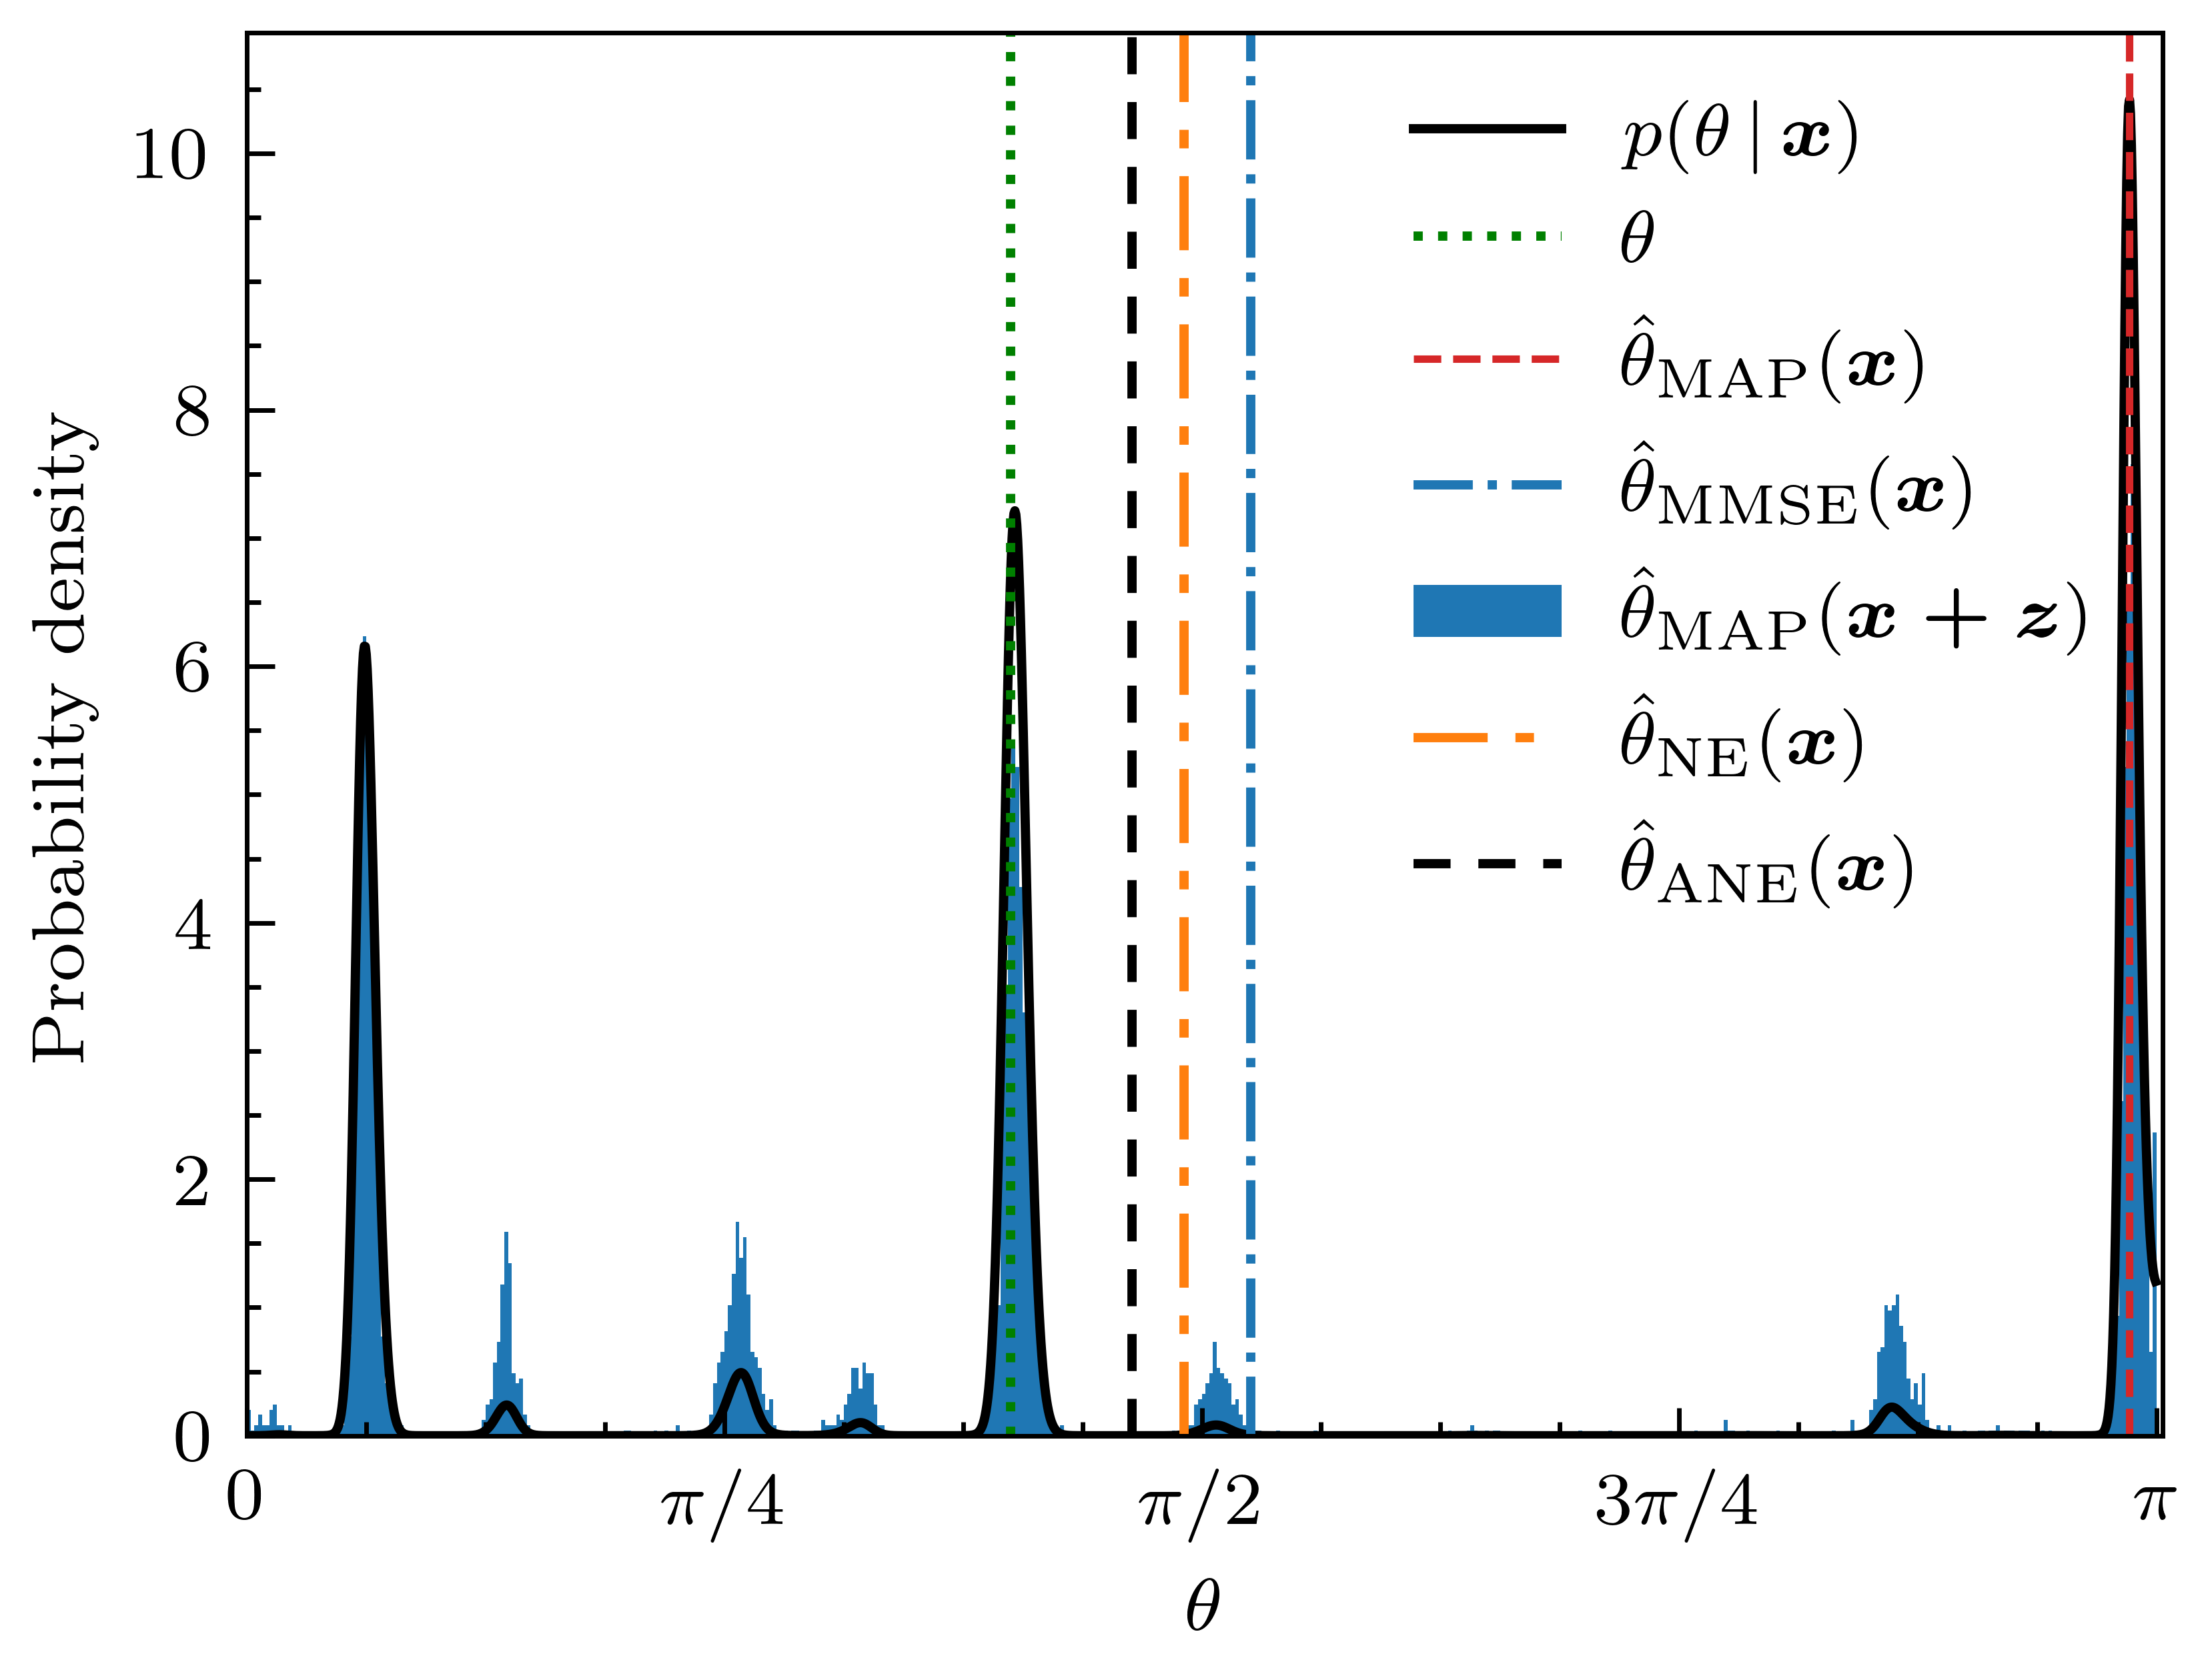

In [7]:
import math
import torch
import matplotlib as mpl
import matplotlib.pyplot as plt
import scienceplots

# -------------------------------------------------------------------------
# 全局学术样式配置 (SciencePlots + IEEE 规范)
# -------------------------------------------------------------------------
plt.style.use(['science', 'ieee'])
mpl.rcParams['font.serif'] = ['Times New Roman']
mpl.rcParams['figure.dpi'] = 1000
mpl.rcParams['axes.unicode_minus'] = False

# 如果开启了 usetex，确保导入 amsmath 以支持 \boldsymbol
mpl.rcParams['text.latex.preamble'] = r'\usepackage{amsmath}'

# 定义符合 IEEE 单栏论文的标准尺寸
FIG_SIZE = (3.3, 2.5) 
fig_a, ax_a = plt.subplots(figsize=FIG_SIZE, constrained_layout=True)

# 显式关闭网格线
ax_a.grid(False)
ax_a.tick_params(
    axis="both",
    which="both",
    top=False,
    right=False
)
# 绘制后验概率密度
ax_a.plot(phi.numpy(), post_a.numpy(),ls="-", color="k",label=r"$p(\theta\,|\,\boldsymbol{x})$")

# 绘制四条垂直线
ax_a.axvline(th_a, ls=":", c="g", lw=1, label=r"$\theta$")

ax_a.axvline(map_a, c="tab:red", ls="--", lw=0.8, label=r"$\hat\theta_{\mathrm{MAP}}(\boldsymbol{x})$")

ax_a.axvline(mmse_a, c="tab:blue", ls="-.", lw=1, label=r"$\hat\theta_{\mathrm{MMSE}}(\boldsymbol{x})$")

ane_a4

# 噪声增强估计 (noise-enhanced estimate, Eq. (theta_ne))
ax_a.hist(th_pert.numpy(), bins=512, range=(0.0, math.pi), density=True,
          color="tab:blue", label=r"$\hat\theta_{\mathrm{MAP}}(\boldsymbol{x+z})$")
ax_a.axvline(ne_a, c="tab:orange", ls=(0, (8, 3, 2, 3)), lw=1, label=r"$\hat\theta_{\mathrm{NE}}(\boldsymbol{x})$")

ax_a.axvline(ane_a4, c="k", ls=(0, (4, 3, 4, 3)), lw=1, label=r"$\hat\theta_{\mathrm{ANE}}(\boldsymbol{x})$")
# -------------------------------------------------------------------------

# 坐标轴与刻度设置
ax_a.set(xlabel=r"$\theta$", ylabel=r"Probability density", xlim=(0, math.pi+0.01))

pi_ticks_4 = [0, math.pi/4, math.pi/2, 3*math.pi/4, math.pi]
pi_labels_4 = [r'$0$', r'$\pi/4$', r'$\pi/2$', r'$3\pi/4$', r'$\pi$']
ax_a.set_xticks(pi_ticks_4)
ax_a.set_xticklabels(pi_labels_4)
ax_a.legend(loc="upper right")
plt.show()
fig_a.savefig("D:/加权最小二乘/Fig1.pdf", dpi=1000)   # was: D:/加权最小二乘/Fig1.pdf
fig_a.savefig("Fig1.png", dpi=300)    # quick-look raster copy

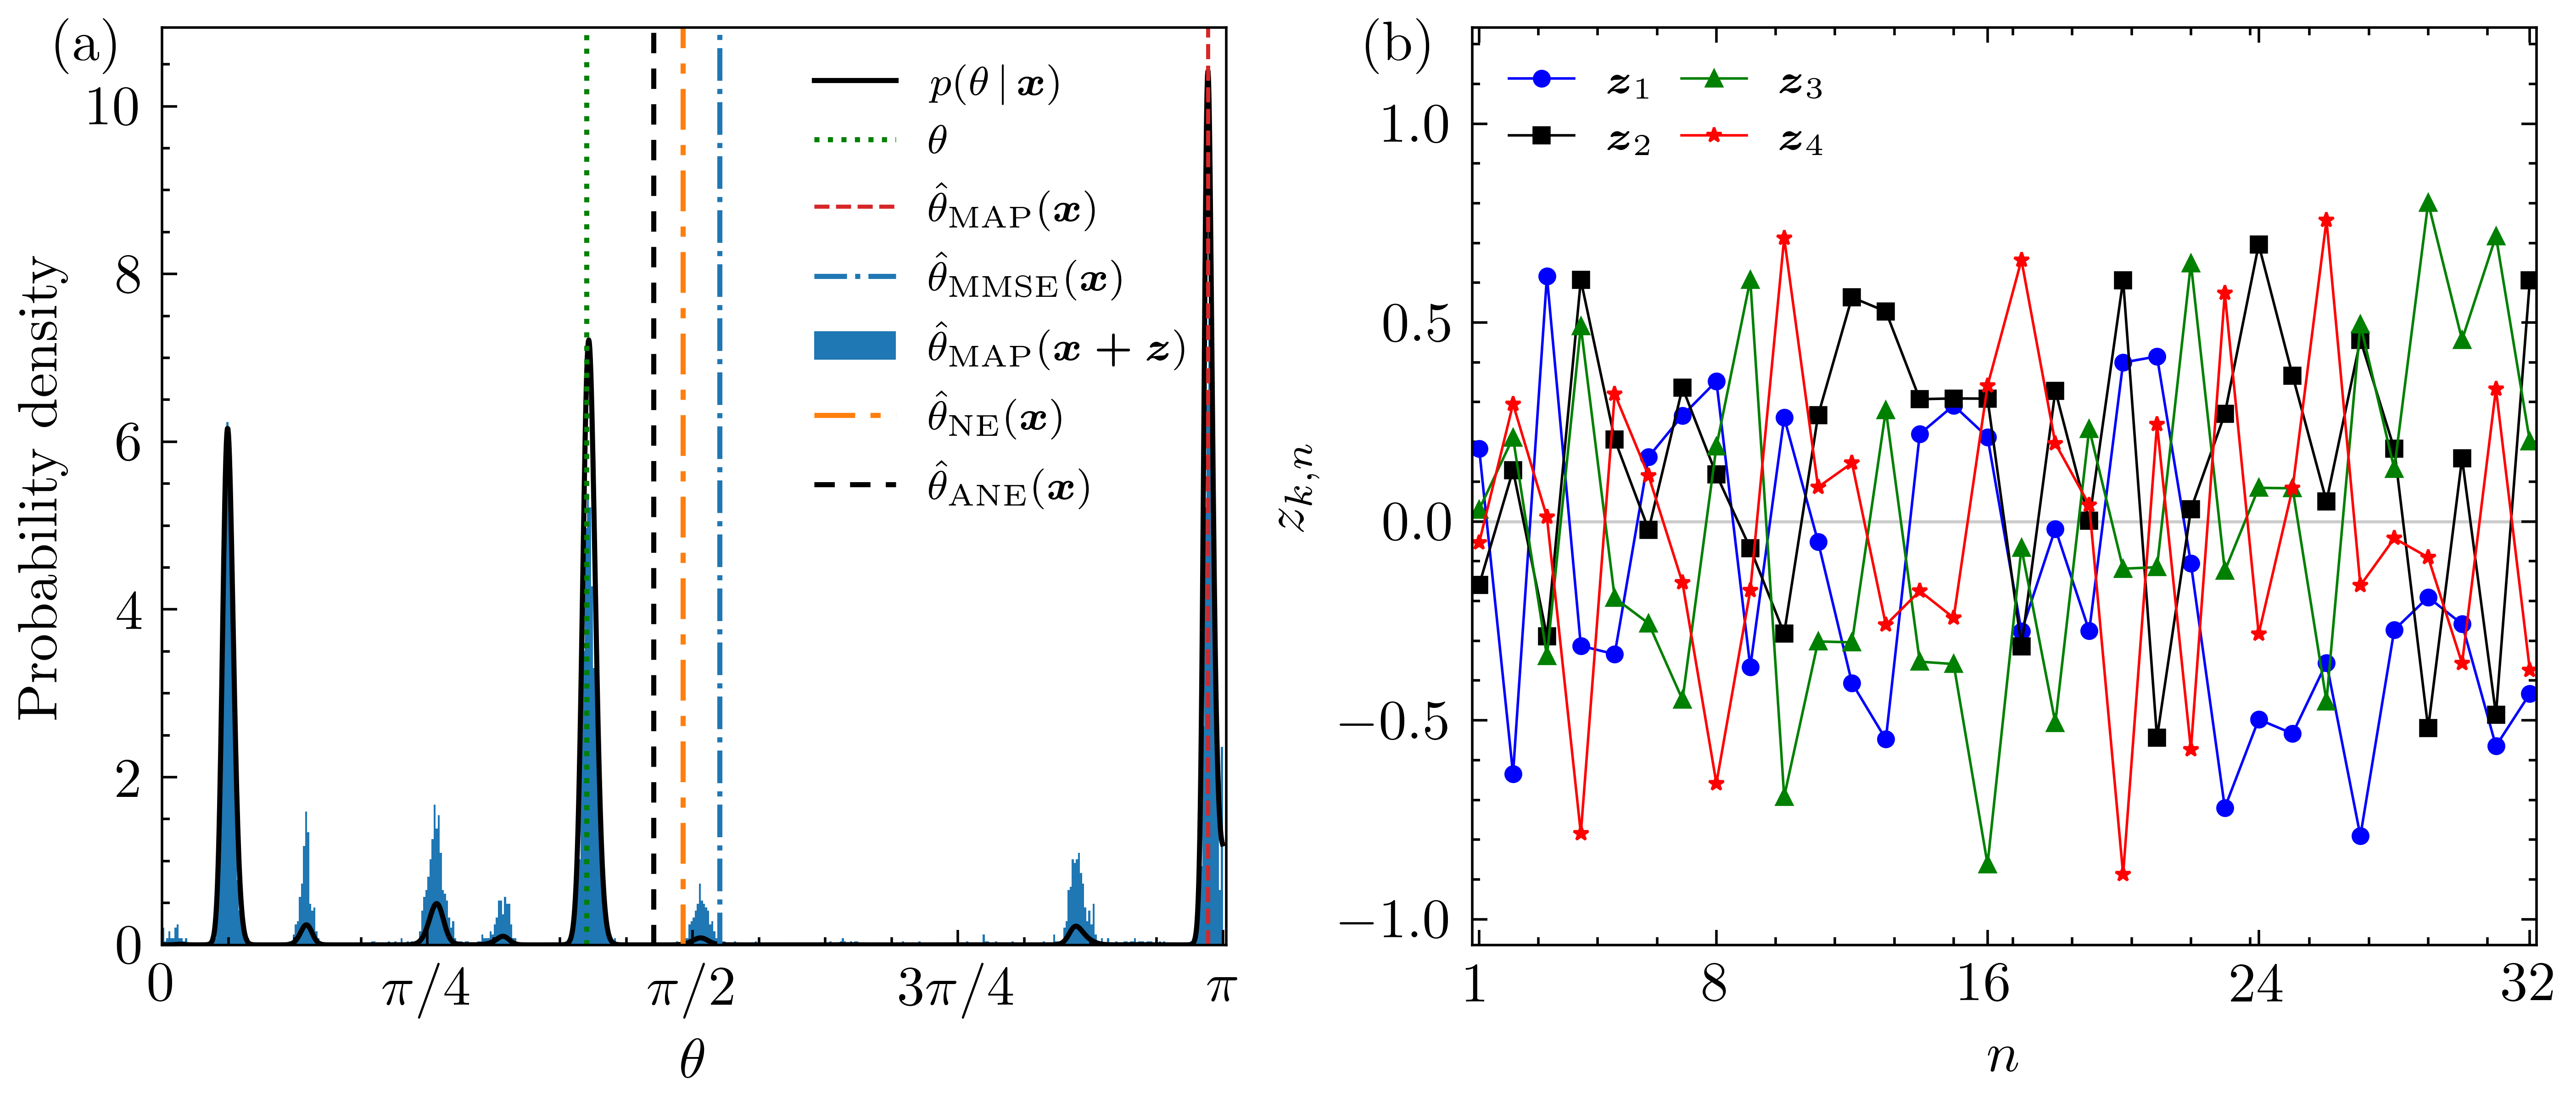

In [37]:
import math
import torch
import matplotlib as mpl
import matplotlib.pyplot as plt
import scienceplots

# =========================================================================
# Global academic style: SciencePlots + IEEE
# =========================================================================
plt.style.use(['science', 'ieee'])

mpl.rcParams['font.serif'] = ['Times New Roman']
mpl.rcParams['figure.dpi'] = 1000
mpl.rcParams['axes.unicode_minus'] = False
mpl.rcParams['text.latex.preamble'] = r'\usepackage{amsmath}'

mpl.rcParams.update({
    'font.family'       : 'serif',
    'font.serif'        : ['Times New Roman'],
    'mathtext.fontset'  : 'stix',
    'font.size'         : 8,
    'axes.labelsize'    : 8,
    'legend.fontsize'   : 8,
    'figure.dpi'        : 800,
    'axes.unicode_minus': False,
})

# =========================================================================
# Combined IEEE two-column figure
# =========================================================================
fig, (ax_s, ax_m) = plt.subplots(
    1, 2,
    figsize=(7, 3),
    constrained_layout=True
)

# =========================================================================
# (a) Posterior density and estimators
# =========================================================================
ax_s.grid(False)
ax_s.tick_params(
    axis="both",
    which="both",
    top=False,
    right=False
)

# Posterior probability density
ax_s.plot(
    phi.numpy(),
    post_a.numpy(),
    ls="-",
    color="k",
    label=r"$p(\theta\,|\,\boldsymbol{x})$"
)

# True parameter
ax_s.axvline(
    th_a,
    ls=":",
    c="g",
    lw=1,
    label=r"$\theta$"
)

# MAP
ax_s.axvline(
    map_a,
    c="tab:red",
    ls="--",
    lw=0.8,
    label=r"$\hat\theta_{\mathrm{MAP}}(\boldsymbol{x})$"
)

# MMSE
ax_s.axvline(
    mmse_a,
    c="tab:blue",
    ls="-.",
    lw=1,
    label=r"$\hat\theta_{\mathrm{MMSE}}(\boldsymbol{x})$"
)

# MAP under noise perturbation
ax_s.hist(
    th_pert.numpy(),
    bins=512,
    range=(0.0, math.pi),
    density=True,
    color="tab:blue",
    label=r"$\hat\theta_{\mathrm{MAP}}(\boldsymbol{x+z})$"
)

# NE
ax_s.axvline(
    ne_a,
    c="tab:orange",
    ls=(0, (8, 3, 2, 3)),
    lw=1,
    label=r"$\hat\theta_{\mathrm{NE}}(\boldsymbol{x})$"
)

# ANE
ax_s.axvline(
    ane_a4,
    c="k",
    ls=(0, (4, 3, 4, 3)),
    lw=1,
    label=r"$\hat\theta_{\mathrm{ANE}}(\boldsymbol{x})$"
)

# Axis settings
ax_s.set(
    xlabel=r"$\theta$",
    ylabel=r"Probability density",
    xlim=(0, math.pi + 0.01)
)
ax_s.set_xlabel(r"$\theta$", fontsize=11)
ax_s.set_ylabel(r"Probability density", fontsize=11)

pi_ticks_4 = [
    0,
    math.pi / 4,
    math.pi / 2,
    3 * math.pi / 4,
    math.pi
]

pi_labels_4 = [
    r'$0$',
    r'$\pi/4$',
    r'$\pi/2$',
    r'$3\pi/4$',
    r'$\pi$'
]

ax_s.set_xticks(pi_ticks_4)
ax_s.set_xticklabels(pi_labels_4,fontsize=11)
ax_s.tick_params(axis='both', labelsize=11)
ax_s.legend(
    loc="upper right",
    fontsize=8
)

# Panel label
ax_s.text(
    -0.1, 1.01,
    r'$\mathrm{(a)}$',
    transform=ax_s.transAxes,
    ha='left',
    va='top',
    fontsize=11
)


# =========================================================================
# (b) Optimal noise perturbations
# =========================================================================
ax_m.grid(False)

# Zero reference line
ax_m.axhline(
    0.0,
    color="0.8",
    lw=0.6,
    zorder=0
)

idx = torch.arange(1, N + 1).numpy()

cols = [
    "b",
    "k",
    "g",
    "r"
]

marks = [
    "o",
    "s",
    "^",
    "*"
]

for k in range(K):

    nk = (Z_star[k].norm() / sigv).item()

    ax_m.plot(
        idx,
        Z_star[k].numpy(),
        lw=0.5,
        color=cols[k],
        ls="-",
        marker=marks[k],
        ms=3,
        markevery=1,
        markeredgewidth=0.5,
        label=(
            r"$\boldsymbol{z}_{" + f"{k + 1}" + r"}$")
    )

ax_m.set(
    xlabel=r"$n$",
    ylabel=r"$z_{k,n}$",
    xlim=(0.8, N+0.2)
)

ax_m.set_xlabel(r"$n$", fontsize=11)
ax_m.set_ylabel(r"$z_{k,n}$", fontsize=11)
ax_m.tick_params(axis='both', labelsize=11)
ax_m.set_xticks([
    1,
    8,
    16,
    24,
    32
])

zmax = float(Z_star.abs().max())
zmax = zmax if zmax > 0 else 1.0

ax_m.set_ylim(
    -1.2*zmax,
    1.4 * zmax
)

ax_m.legend(
    loc="upper left",
    ncol=2,
    columnspacing=0.7,
    handlelength=1.6,
    fontsize=8
)

# Panel label
ax_m.text(
    -0.1, 1.01,
    r'$\mathrm{(b)}$',
    transform=ax_m.transAxes,
    ha='left',
    va='top',
    fontsize=11
)


# =========================================================================
# Final layout
# =========================================================================
plt.show()

In [39]:
fig.savefig(
    'D:/加权最小二乘/Fig1.pdf',
    dpi=1000,
    bbox_inches='tight'
)

In [40]:
fig.savefig(
    'D:/加权最小二乘/Fig1.eps',
    dpi=1000,
    bbox_inches='tight'
)